# Обзор бизнес-показателей маркетплейса

- Автор: Меркулова Алёна
- Дата: 2026-09-22

## Вводные по кейсу

Быстрорастущий маркетплейс, который определился с нишей и начал приносить прибыль, но вся отчетность велась в Excel и не был полноценно реализован datadriven-подход, по мере роста бизнеса появился запрос на системный анализ и сбор продуктовых данных для его дальнейшего развития. Работа с данными за 2024 год.

***Цель:*** 

Проанализировав бизнес-показатели маркетплейса, собрать целостную картину о продукте: его аудитория, каналы развития и прибыльные категории товаров, а также найти узкие места для дальнейшего развития

***Задачи:***

- Первичный анализ и сбор данных.
- Обзор ключевых метрик.
- Оценка метрик монетизации и юнит-экономики.
- Поиск инсайтов и точек роста. Сегментация и формулирование гипотез.
- Подготовка эксперимента и подведение его итогов.


## Описание данных

## Таблица `Users`

| Поле              | Описание                                       |
|-------------------|------------------------------------------------|
| `user_id`         | Уникальный идентификатор пользователя.         |
| `registration_date` | Дата регистрации пользователя.                |
| `age`             | Возраст пользователя.                          |
| `gender`          | Пол.                                |
| `region`          | Регион.                                        |
| `acq_channel`     | Канал привлечения.                             |
| `buyer_segment`   | Сегмент покупателя.                            |
| `cohort_week`     | Неделя привлечения.|
| `cohort_month`    | Месяц привлечения. |

---

## Таблица `Events`

| Поле          | Описание                                                                 |
|---------------|--------------------------------------------------------------------------|
| `event_id`    | Уникальный идентификатор события.                                        |
| `user_id`     | Идентификатор пользователя.                                              |
| `event_date`  | Дата события.                                                            |
| `event_type`  | Тип события.   |
| `os`          | Операционная система.               |
| `device`      | Тип устройства.                                |
| `product_name`| Наименование товара, к которому относится событие (если применимо).      |
| `event_week`  | Неделя события.                                          |
| `event_month` | Месяц события .                                           |

---

## Таблица `Orders`

| Поле          | Описание                                                                 |
|---------------|--------------------------------------------------------------------------|
| `order_id`    | Уникальный идентификатор заказа.                                         |
| `user_id`     | Идентификатор пользователя, который сделал заказ |
| `order_date`  | Дата и время оформления заказа.                                          |
| `product_name`| Наименование товара.                                                     |
| `quantity`    | Количество единиц товара в заказе.                                       |
| `unit_price`  | Цена за одну единицу товара.                                             |
| `total_price` | Итоговая сумма заказа.                                                   |
| `category_name` | Наименование категории товара.                                         |
| `order_week`  | Неделя заказа.                                           |
| `order_month` | Месяц заказа.                                            |


## Таблица `Campaign_costs`

| Поле         | Описание                                                                 |
|--------------|--------------------------------------------------------------------------|
| `acq_channel`| Канал привлечения.  |
| `spend_month`| Месяц, в который был потрачен бюджет (отражает период, в котором были привлечены пользователи)                      |
| `budget`     | Маркетинговый бюджет (в денежном выражении), потраченный на данный канал в указанном месяце.                           |



## Описание событий

| Событие             | Описание                                                                                  |
|---------------------|-------------------------------------------------------------------------------------------|
| `page_view`         | Открытие любой страницы сайта или приложения пользователем.                                |
| `product_view`      | Просмотр страницы конкретного товара.                                                     |
| `product_click`     | Клик по товару (например, из списка товаров или на баннере).                              |
| `add_to_cart`       | Добавление товара в корзину.                                                              |
| `remove_from_cart`  | Удаление товара из корзины.                                                               |
| `search`            | Выполнение поиска по сайту или приложению.                                                |
| `filter_apply`      | Применение фильтра (например, по цене, бренду, категории).                                |
| `checkout_start`    | Начало оформления заказа (переход к оформлению корзины).                                  |
| `checkout_complete` | Завершение оформления заказа (не гарантирует покупку, покупка зависит от факта оплаты).                                          |
| `user_login`        | Вход пользователя в личный кабинет или аккаунт.                                           |
| `user_logout`       | Выход пользователя из аккаунта.                                                           |
| `wishlist_add`      | Добавление товара в список желаемого (wishlist).                                          |
| `category_view`     | Просмотр страницы категории товаров.                                                      |
| `banner_click`      | Клик по рекламному баннеру на сайте или в приложении.                                     |
| `promo_view`        | Просмотр промо-акции или специального предложения.                                        |


## Выручка маркетплейса = 5% от total_price

## 1. Загрузка данных и предобработка

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind

In [2]:
#Загрузка данных
df_orders = pd.read_csv('data/pa_marketplace_orders.csv',parse_dates=['order_date', 'order_week','order_month'])
df_campaign_costs = pd.read_csv('data/pa_marketplace_campaign_costs.csv', index_col=0, parse_dates=['spend_month'])
df_users = pd.read_csv('data/pa_marketplace_users.csv',parse_dates=['registration_date','cohort_week','cohort_month'])
df_events = pd.read_csv('data/pa_marketplace_events.csv',parse_dates=['event_date','event_week','event_month'])

#Знакомство с данными и предобработка df_orders
print(df_orders.info())
display(df_orders.head())
display(df_orders.tail())
print(df_orders[['quantity','unit_price','total_price']].describe())
print()

#Проверка max/min для оптимизации типа данных
print(df_orders['order_id'].max(), df_orders['order_id'].min())
print(df_orders['user_id'].max(), df_orders['user_id'].min())
print(df_orders['quantity'].max(), df_orders['quantity'].min())

df_orders['order_id'] = df_orders['order_id'].astype('int32')
df_orders['user_id'] = df_orders['user_id'].astype('int32')
df_orders['quantity'] = df_orders['quantity'].astype('int8')
print()

#Проверка
print(df_orders.dtypes)

#Проверяем явные и неявные дубли
duplicates_orders = df_orders.duplicated().sum()
implicit_duplicates_orders = df_orders[df_orders.duplicated(subset=['user_id', 'order_id'], keep=False)]

print()
print(f"Явных: {duplicates_orders}")
print(f"Неявных строк: {len(implicit_duplicates_orders)}")
print()

#Проверка категориальных столбцов
print(df_orders['category_name'].unique())

<class 'pandas.DataFrame'>
RangeIndex: 31357 entries, 0 to 31356
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       31357 non-null  int64         
 1   user_id        31357 non-null  int64         
 2   order_date     31357 non-null  datetime64[us]
 3   product_name   31357 non-null  str           
 4   quantity       31357 non-null  int64         
 5   unit_price     31357 non-null  float64       
 6   total_price    31357 non-null  float64       
 7   category_name  31357 non-null  str           
 8   order_week     31357 non-null  datetime64[us]
 9   order_month    31357 non-null  datetime64[us]
dtypes: datetime64[us](3), float64(2), int64(3), str(2)
memory usage: 2.4 MB
None


,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
0,1,3,2024-01-19 01:52:52,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
1,2,3,2024-01-19 01:52:52,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
2,3,3,2024-01-19 01:52:52,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
3,4,3,2024-01-25 13:59:38,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
4,5,3,2024-01-25 13:59:38,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01


,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
31352,31774,44719,2024-12-30 02:21:00,Дезодорант,2,697.72,1395.44,Средства для ухода,2024-12-30,2024-12-01
31353,31775,44719,2024-12-30 02:21:00,Поло Ralph Lauren,2,5446.69,10893.38,Мужская одежда,2024-12-30,2024-12-01
31354,31776,44777,2024-12-30 17:45:00,Футболка дышащая,1,3114.57,3114.57,Одежда для спорта,2024-12-30,2024-12-01
31355,31777,44777,2024-12-30 17:45:00,Костюм спортивный,2,6999.82,13999.64,Одежда для спорта,2024-12-30,2024-12-01
31356,31791,44906,2024-12-31 18:21:35,Скраб для тела,1,339.00,339.00,Средства для ухода,2024-12-30,2024-12-01


           quantity    unit_price    total_price
count  31357.000000  31357.000000   31357.000000
mean       2.006857   6986.909334   14030.175560
std        0.820073   8170.131920   18667.398146
min        1.000000    339.000000     339.000000
25%        1.000000   2155.370000    3776.740000
50%        2.000000   4406.630000    7554.640000
75%        3.000000   9395.950000   17657.460000
max        3.000000  63932.380000  191797.140000

31791 1
44906 3
3 1

order_id                  int32
user_id                   int32
order_date       datetime64[us]
product_name                str
quantity                   int8
unit_price              float64
total_price             float64
category_name               str
order_week       datetime64[us]
order_month      datetime64[us]
dtype: object

Явных: 0
Неявных строк: 0

<StringArray>
['Инструменты и садовый инвентарь',                'Продукты питания',
                  'Женская одежда',         'Аксессуары для гаджетов',
               'Оде

- df_orders состоит из 31357 строк, 10 столбцов. Пропусков, явных и неявных дублей нет, в категориальном столбце все значения уникальные. При загрузке данных скорректирован тип даты и времени из (object) и далее оптимизирован тип данных для числовых столбцов (int64->int32/int8, где позволяет объем данных). По числовым столбцам: quantity стабильный, без выбросов, в unit_price есть дорогие товары, которые тянут среднее вверх, широкий разброс; total_price сильно скошено вправо, есть крупные заказы, лучше ориентироваться на медиану.

In [3]:
#Знакомство с данными и предобработка df_users
print(df_users.info())
display(df_users.head())
display(df_users.tail())
print()

#Оптимизация типа данных
df_users['user_id'] = df_users['user_id'].astype('int32')
df_users['age'] = df_users['age'].astype('int8')
print()

#Проверка
print(df_users.dtypes)

#Проверяем явные и неявные дубли
duplicates_users = df_users.duplicated().sum()
implicit_duplicates_users = df_users[df_users.duplicated(subset=['user_id', 'acq_channel','region'], keep=False)]

print()
print(f"Явных: {duplicates_users}")
print(f"Неявных строк: {len(implicit_duplicates_users)}")
print()

#Проверка категориальных столбцов
print(df_users['buyer_segment'].unique())
print(df_users['region'].unique())
print(df_users['acq_channel'].unique())

<class 'pandas.DataFrame'>
RangeIndex: 44151 entries, 0 to 44150
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            44151 non-null  int64         
 1   registration_date  44151 non-null  datetime64[us]
 2   age                44151 non-null  int64         
 3   gender             44151 non-null  str           
 4   region             44151 non-null  str           
 5   acq_channel        44151 non-null  str           
 6   buyer_segment      44151 non-null  str           
 7   cohort_week        44151 non-null  datetime64[us]
 8   cohort_month       44151 non-null  datetime64[us]
dtypes: datetime64[us](3), int64(2), str(4)
memory usage: 3.0 MB
None


,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month
0,1,2024-01-01 00:47:00,35,M,Москва,Google Ads,regular,2024-01-01,2024-01-01
1,2,2024-01-01 19:01:00,53,M,Москва,Email Marketing,rare,2024-01-01,2024-01-01
2,3,2024-01-01 04:13:00,66,F,Санкт-Петербург,Google Ads,regular,2024-01-01,2024-01-01
3,4,2024-01-01 17:18:00,58,M,Краснодар,Affiliate,one_time,2024-01-01,2024-01-01
4,5,2024-01-01 08:29:00,58,F,Другие регионы,Google Ads,regular,2024-01-01,2024-01-01


,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month
44146,44959,2024-12-31 06:09:00,60,M,Другие регионы,TikTok,rare,2024-12-30,2024-12-01
44147,44960,2024-12-31 01:40:00,63,M,Москва,TikTok,regular,2024-12-30,2024-12-01
44148,44961,2024-12-31 02:27:00,32,F,Санкт-Петербург,TikTok,medium,2024-12-30,2024-12-01
44149,44962,2024-12-31 21:47:00,67,F,Санкт-Петербург,TikTok,rare,2024-12-30,2024-12-01
44150,44963,2024-12-31 02:25:00,21,F,Москва,TikTok,regular,2024-12-30,2024-12-01




user_id                       int32
registration_date    datetime64[us]
age                            int8
gender                          str
region                          str
acq_channel                     str
buyer_segment                   str
cohort_week          datetime64[us]
cohort_month         datetime64[us]
dtype: object

Явных: 0
Неявных строк: 0

<StringArray>
['regular', 'rare', 'one_time', 'medium']
Length: 4, dtype: str
<StringArray>
[            'Москва',    'Санкт-Петербург',          'Краснодар',
     'Другие регионы',    'Нижний Новгород',       'Екатеринбург',
 'Московская область',        'Новосибирск',     'Ростов-на-Дону']
Length: 9, dtype: str
<StringArray>
['Google Ads', 'Email Marketing', 'Affiliate', 'SEO', 'Social Media',
 'TikTok']
Length: 6, dtype: str


- df_users состоит из 44151 строки, 9 столбцов. Пропусков, явных и неявных дублей нет, в категориальных столбцах все значения уникальные. При загрузке данных сразу скорректирован тип даты и времени (из object) и далее оптимизирован тип данных для числовых столбцов (int64->int32/int8, где позволяет объем данных).

In [4]:
#Знакомство с данными и предобработка df_events
print(df_events.info())
display(df_events.head())
display(df_events.tail())
print()

#Оптимизация типа данных
df_events['user_id'] = df_events['user_id'].astype('int32')
df_events['event_id'] = df_events['event_id'].astype('int32')
print()

#Проверка
print(df_events.dtypes)
print()

#Пропуски
missing_data = df_events['product_name'].isna().sum()
total = len(df_events)
print(f"Пропусков в product_name: в абсолютном  - {missing_data} и в относительном - {missing_data/total*100:.2f}")

#Проверяем явные и неявные дубли
duplicates_events = df_events.duplicated().sum()
implicit_duplicates_events = df_events[df_events.duplicated(subset=['user_id', 'event_id'], keep=False)]

print()
print(f"Явных: {duplicates_events}")
print(f"Неявных строк: {len(implicit_duplicates_events)}")
print()

#Проверка категориальных столбцов
print(df_events['os'].unique())
print(df_events['device'].unique())
print(df_events['event_type'].unique())

<class 'pandas.DataFrame'>
RangeIndex: 785859 entries, 0 to 785858
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   event_id      785859 non-null  int64         
 1   user_id       785859 non-null  int64         
 2   event_date    785859 non-null  datetime64[us]
 3   event_type    785859 non-null  str           
 4   os            785859 non-null  str           
 5   device        785859 non-null  str           
 6   product_name  385740 non-null  str           
 7   event_week    785859 non-null  datetime64[us]
 8   event_month   785859 non-null  datetime64[us]
dtypes: datetime64[us](3), int64(2), str(4)
memory usage: 54.0 MB
None


,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month
0,3132,100,2024-01-01,page_view,iOS,mobile,NaN,2024-01-01,2024-01-01
1,3133,100,2024-01-01,product_view,iOS,mobile,Шорты для тренировок,2024-01-01,2024-01-01
2,3134,100,2024-01-01,product_click,iOS,mobile,Куртка детская,2024-01-01,2024-01-01
3,3135,100,2024-01-01,add_to_cart,iOS,mobile,Балетки классические,2024-01-01,2024-01-01
4,3136,100,2024-01-01,checkout_start,iOS,mobile,NaN,2024-01-01,2024-01-01


,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month
785854,838155,44749,2024-12-31,checkout_complete,Android,mobile,NaN,2024-12-30,2024-12-01
785855,838156,44749,2024-12-31,filter_apply,Android,mobile,NaN,2024-12-30,2024-12-01
785856,838157,44749,2024-12-31,wishlist_add,Android,mobile,Лоферы лакированные,2024-12-30,2024-12-01
785857,807643,41393,2024-12-31,page_view,Windows,tablet,NaN,2024-12-30,2024-12-01
785858,807644,41393,2024-12-31,product_view,Windows,tablet,Лак для ногтей,2024-12-30,2024-12-01




event_id                 int32
user_id                  int32
event_date      datetime64[us]
event_type                 str
os                         str
device                     str
product_name               str
event_week      datetime64[us]
event_month     datetime64[us]
dtype: object

Пропусков в product_name: в абсолютном  - 400119 и в относительном - 50.91

Явных: 0
Неявных строк: 0

<StringArray>
['iOS', 'Windows', 'macOS', 'Android']
Length: 4, dtype: str
<StringArray>
['mobile', 'desktop', 'tablet']
Length: 3, dtype: str
<StringArray>
[        'page_view',      'product_view',     'product_click',
       'add_to_cart',    'checkout_start', 'checkout_complete',
       'user_logout',            'search',     'category_view',
      'filter_apply',        'promo_view',      'wishlist_add',
        'user_login',      'banner_click',  'remove_from_cart']
Length: 15, dtype: str


- df_events состоит из 785859 строк, 9 столбцов. В столбце product_name 50,9% пропусков, явных и неявных дублей нет, в категориальных столбцах все значения уникальные. При загрузке данных сразу скорректирован тип даты и времени (из object) и далее оптимизирован тип данных для числовых столбцов (int64->int32)

<class 'pandas.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   acq_channel  88 non-null     str           
 1   spend_month  88 non-null     datetime64[us]
 2   budget       88 non-null     float64       
dtypes: datetime64[us](1), float64(1), str(1)
memory usage: 2.2 KB
None


,acq_channel,spend_month,budget
Unnamed: 0,,,
0,Affiliate,2024-01-01,179343.3875
1,Affiliate,2024-02-01,175488.4875
2,Affiliate,2024-03-01,164543.4750
3,Affiliate,2024-04-01,186869.9750
4,Affiliate,2024-05-01,166443.7750


                      spend_month        budget
count                          88  8.800000e+01
mean   2024-06-26 09:49:05.454545  2.196269e+05
min           2024-01-01 00:00:00  6.674101e+03
25%           2024-04-01 00:00:00  4.204593e+04
50%           2024-07-01 00:00:00  1.114376e+05
75%           2024-10-01 00:00:00  1.726050e+05
max           2025-01-01 00:00:00  1.533683e+06
std                           NaN  3.373531e+05

<StringArray>
[      'Affiliate',          'Direct', 'Email Marketing',    'Social Media',
      'Google Ads',             'SEO',          'TikTok']
Length: 7, dtype: str


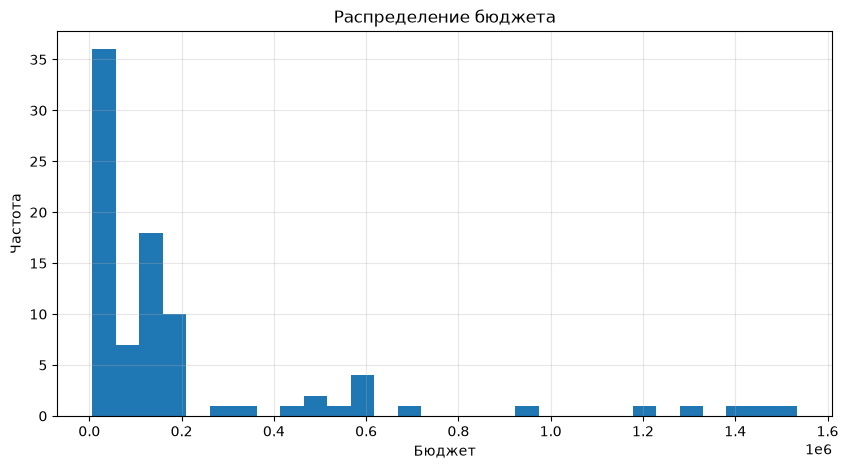

Период расходов: 2024-01-01 00:00:00 — 2025-01-01 00:00:00
Период регистраций: 2024-01-01 00:00:00 — 2024-12-01 00:00:00

Строк за пределами 2024 года: 6, бюджет 1,564,957 руб.
Осталось строк: 82


In [5]:
#Знакомство с данными и предобработка df_campaign_costs
print(df_campaign_costs.info())
display(df_campaign_costs.head())
print(df_campaign_costs.describe())
print()
#Проверка категориальных столбцов
print(df_campaign_costs['acq_channel'].unique())

plt.figure(figsize=(10, 5))
plt.hist(df_campaign_costs['budget'], bins=30)
plt.title('Распределение бюджета')
plt.xlabel('Бюджет')
plt.ylabel('Частота')
plt.grid(alpha=0.3)
plt.show()

df_campaign_costs.sort_values('budget', ascending=False).head()

#Проверка периода
print('Период расходов:', df_campaign_costs['spend_month'].min(), '—', df_campaign_costs['spend_month'].max())
print('Период регистраций:', df_users['cohort_month'].min(), '—', df_users['cohort_month'].max())
print()

#Расходы за пределами периода анализа
outside = df_campaign_costs[df_campaign_costs['spend_month'].dt.year != 2024]
print(f'Строк за пределами 2024 года: {len(outside)}, бюджет {outside["budget"].sum():,.0f} руб.')

#Оставляем только 2024 год
df_campaign_costs = df_campaign_costs[df_campaign_costs['spend_month'].dt.year == 2024]
print(f'Осталось строк: {len(df_campaign_costs)}')

- df_campaign_costs состоял из 88 строк, 3 столбцов, были найдены данные за пределами исследуемого периода - 2024 год, датасет отфильтрован по года, осталось 82 строки. Пропусков нет, в категориальном столбце все значения уникальные. При загрузке данных сразу скорректирован тип даты и времени (из object) и убран индекс. По числовому столбцу budget: есть несколько очень крупных бюджетов (выбросы), которые тянут среднее вверх - площадка TikTok. Стандартное отклонение больше среднего. Большинство кампаний до 200к, длинный хвост вправо до 1,5 млн. Также лучше ориентироваться на медиану.

- С данными познакомились, предобработали, можно приступать к обзору ключевых метрик.

## 2. Обзор ключевых метрик

Полный оборот за 2024 год: 439944215.0
Выручка маркетплейса(5%): 21997210.8


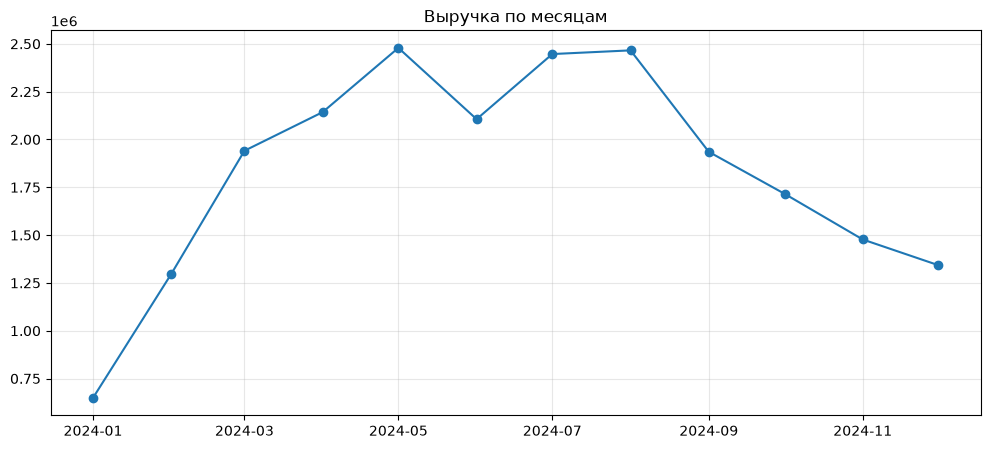

In [6]:
#Расчет основных метрик

#Revenue
df_orders['revenue'] = df_orders['total_price']*0.05
print(f"Полный оборот за 2024 год: {df_orders['total_price'].sum().round(1)}")
print(f"Выручка маркетплейса(5%): {df_orders['revenue'].sum().round(1)}")
revenue_monthly = df_orders.groupby('order_month')['revenue'].sum().reset_index()

plt.figure(figsize=(12, 5))
plt.plot(revenue_monthly['order_month'], revenue_monthly['revenue'], marker='o')
plt.grid(alpha=0.3)
plt.title('Выручка по месяцам')
plt.show()

- Поная выручка мп составила около 22-х млн. С начала года выручка активно росла, достигнув пика в мае, за первые 5 месяцев она выросла в 2,5 раза. Летом она удерживалась выше 2х млн, но с конца лет тренд пошел на спад и мы видим продолжение снижения выручки до конца года. Из хорошего: темпы снижения в конце года заметно ниже, чем темпы роста в начале, но стоит разобраться почему выручка продолжает падать.

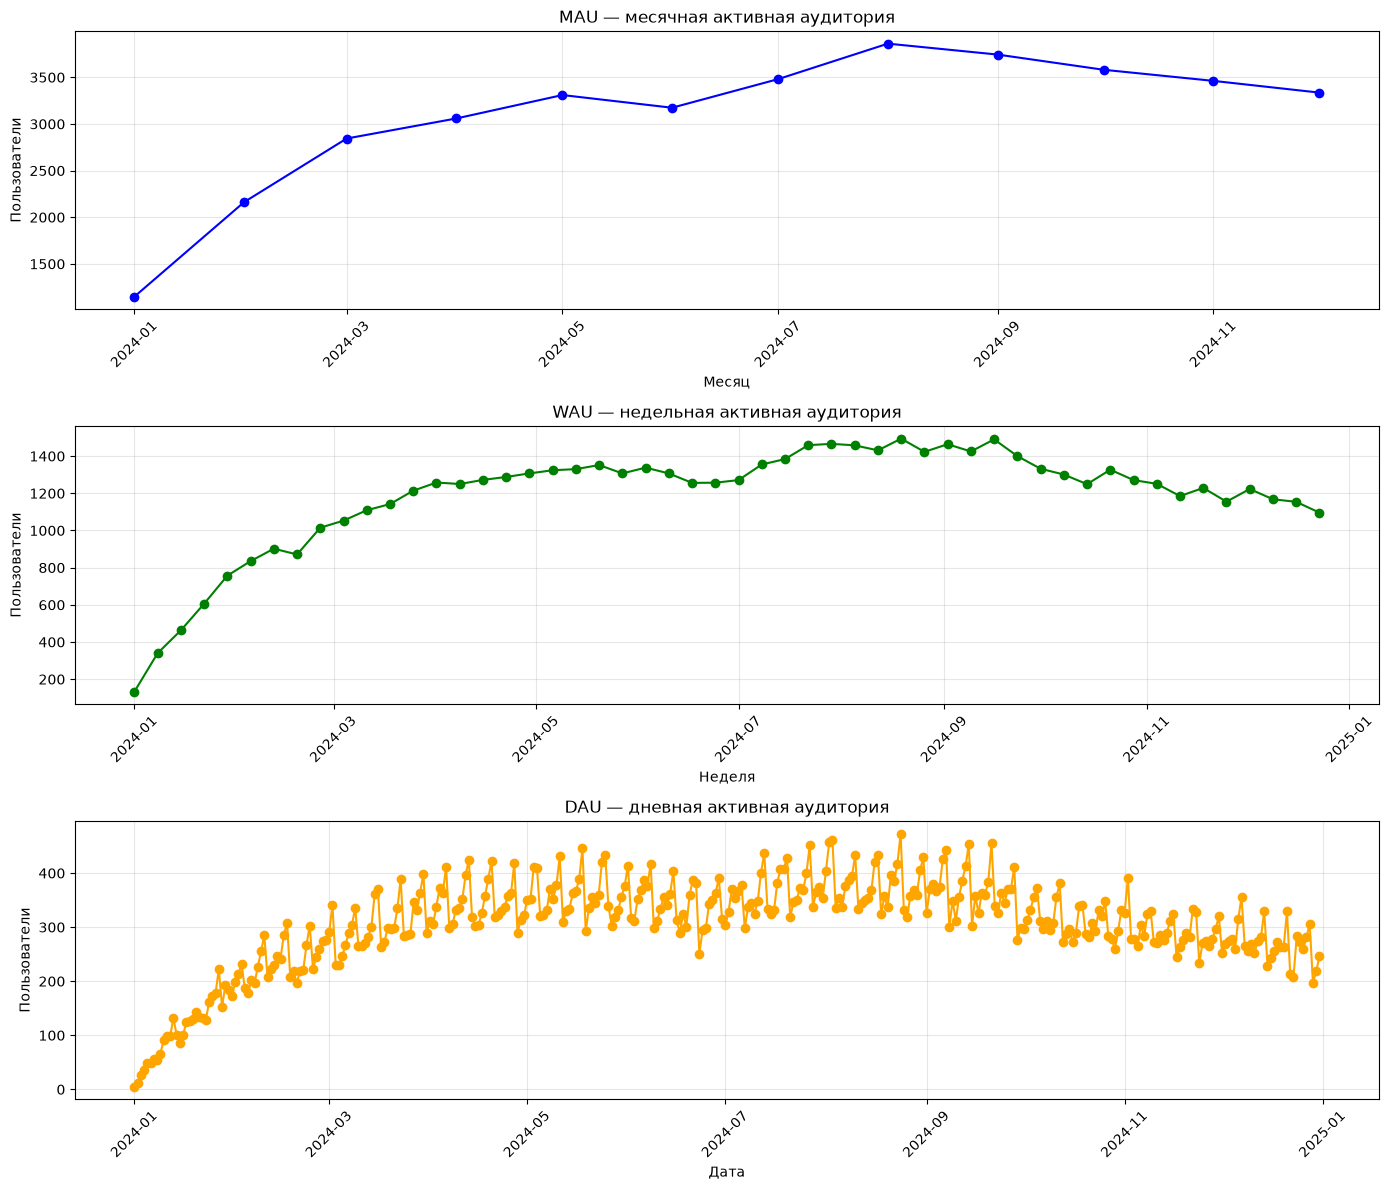

In [7]:
#MAU/WAU/DAU

mau = df_events.groupby('event_month')['user_id'].nunique()
wau = df_events.groupby('event_week')['user_id'].nunique()
dau = df_events.groupby('event_date')['user_id'].nunique()

max_date = df_events['event_date'].max()
# Оставляем только недели, которые полностью закончились
wau = wau[wau.index < max_date - pd.Timedelta(days=7)]

#Строим графики
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

#MAU
axes[0].plot(mau.index, mau.values, marker='o', color='blue')
axes[0].set_title('MAU — месячная активная аудитория')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Пользователи')
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

#WAU
axes[1].plot(wau.index, wau.values, marker='o', color='green')
axes[1].set_title('WAU — недельная активная аудитория')
axes[1].set_xlabel('Неделя')
axes[1].set_ylabel('Пользователи')
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

#DAU
axes[2].plot(dau.index, dau.values, marker='o', color='orange')
axes[2].set_title('DAU — дневная активная аудитория')
axes[2].set_xlabel('Дата')
axes[2].set_ylabel('Пользователи')
axes[2].grid(alpha=0.3)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

- С начала года активно росли метрики активности пользователей, MAU выросла более чем в 2 раза, с августа заметен небольшой спад активности (порядка 11%), тем не менее MAU остается высоким, не опускаясь ниже 3000 с марта. Чуть более активный спад недельной активности и наиболее заметное снижение активности из всех метрик у DAU, где показатель к концу года опустился до уровня февраля.

Средний чек по году: 14,030.18 руб.


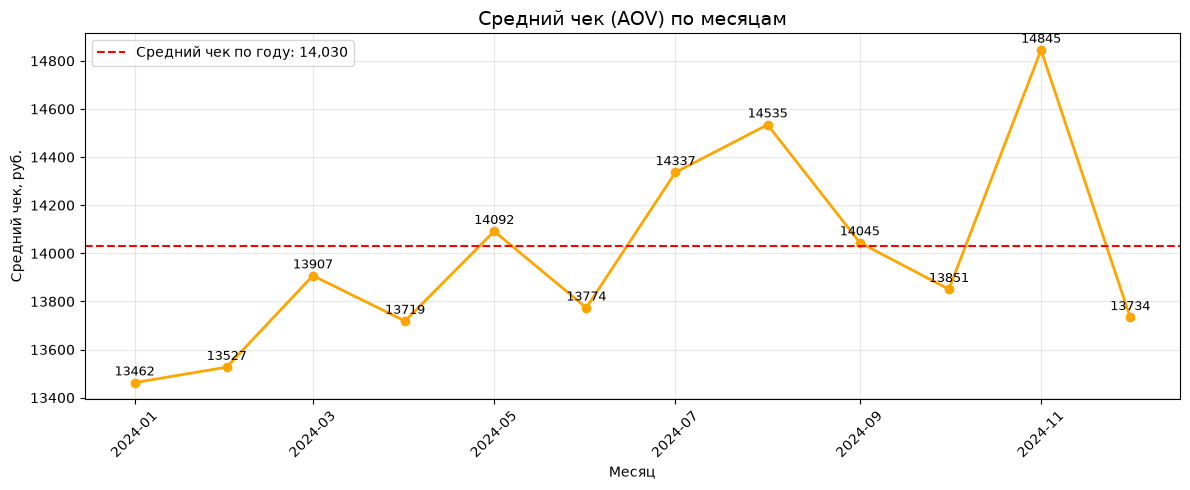

In [8]:
#AOV
aov_total = df_orders['total_price'].mean()
print(f'Средний чек по году: {aov_total:,.2f} руб.')

aov_monthly = df_orders.groupby('order_month')['total_price'].mean()

plt.figure(figsize=(12, 5))
plt.plot(aov_monthly.index, aov_monthly.values, marker='o', color='orange', linewidth=2)

plt.title('Средний чек (AOV) по месяцам', fontsize=14)
plt.xlabel('Месяц')
plt.ylabel('Средний чек, руб.')
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

for x, y in zip(aov_monthly.index, aov_monthly.values):
    plt.text(x, y + 30, f'{y:.0f}', ha='center', fontsize=9)

plt.axhline(aov_total, color='red', linestyle='--', label=f'Средний чек по году: {aov_total:,.0f}')
plt.legend()    
plt.tight_layout()
plt.show()

- Средний чек по году - 14 030 р, колебания в диапазоне 13 462–14 845, то есть разброс около 10%. Выраженного тренда нет: чек не растёт и не падает системно, а скачет вокруг среднего. Два заметных пика: август (14 535) и ноябрь (14 845, максимум года). Ноябрьский почти наверняка связан с распродажами, минимумы приходятся на январь и февраль, что тоже типично для посленовогоднего спада. Стоит обратить внимание на декабрь, тк перед праздниками месяц тоже должен быть сильным, но на фоне ноября заметно проседает, возможно это из-за нетипично большого показателя AOV ранее в ноябре.

Всего пользователей: 44,151
Активных (есть события): 22,138 (50.1%)
Платящих: 8,922 (20.2% от всех, 40.3% от активных)


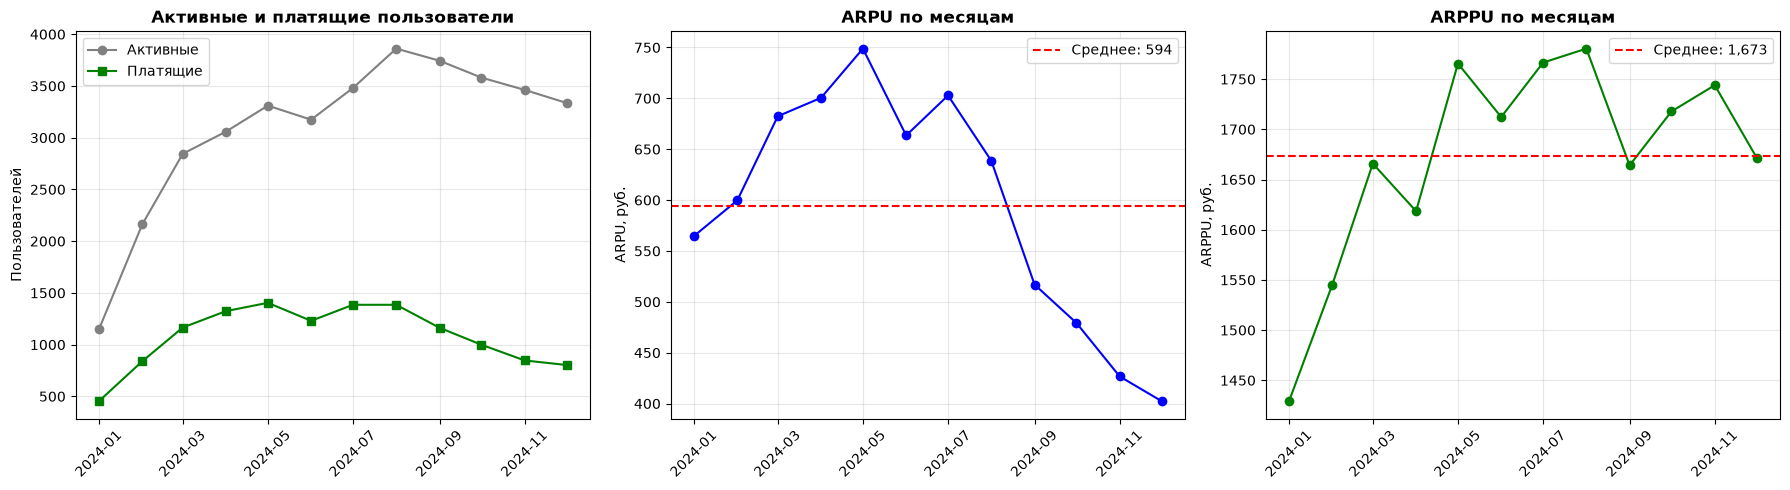

In [9]:
#Общая картина монетизации
total_users = df_users['user_id'].nunique()
active_users = df_events['user_id'].nunique()
paying_users = df_orders['user_id'].nunique()


print(f'Всего пользователей: {total_users:,}')
print(f'Активных (есть события): {active_users:,} ({active_users/total_users*100:.1f}%)')
print(f'Платящих: {paying_users:,} ({paying_users/total_users*100:.1f}% от всех, '
      f'{paying_users/active_users*100:.1f}% от активных)')

#Помесячная динамика
active_monthly = df_events.groupby('event_month')['user_id'].nunique()
paid_monthly = df_orders.groupby('order_month')['user_id'].nunique()
revenue_monthly = df_orders.groupby('order_month')['revenue'].sum()

arpu = revenue_monthly / active_monthly
arppu = revenue_monthly / paid_monthly

#Визуализация
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(active_monthly.index, active_monthly.values, marker='o', label='Активные', color='gray')
axes[0].plot(paid_monthly.index, paid_monthly.values, marker='s', label='Платящие', color='green')
axes[0].set_title('Активные и платящие пользователи', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Пользователей')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(arpu.index, arpu.values, marker='o', color='blue')
axes[1].axhline(arpu.mean(), color='red', linestyle='--', label=f'Среднее: {arpu.mean():,.0f}')
axes[1].set_title('ARPU по месяцам', fontsize=12, fontweight='bold')
axes[1].set_ylabel('ARPU, руб.')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

axes[2].plot(arppu.index, arppu.values, marker='o', color='green')
axes[2].axhline(arppu.mean(), color='red', linestyle='--', label=f'Среднее: {arppu.mean():,.0f}')
axes[2].set_title('ARPPU по месяцам', fontsize=12, fontweight='bold')
axes[2].set_ylabel('ARPPU, руб.')
axes[2].legend()
axes[2].grid(alpha=0.3)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

- Общая монетизация маркетплейса составляет 20% от всех пользователей, конверсия в покупку - 40% (из активных)
- ARPPU колеблется в диапазоне 1550–1780р (январский минимум 1430 - выброс), но без выраженного тренда: значения ходят вокруг среднего 1673р в обе стороны. ARPU при этом падает с 748р в мае до 400р в декабре за счёт снижения доли платящих: число активных пользователей выросло, а количество покупателей с мая сокращается. Рост аудитории во втором полугодии не сопровождался ростом продаж, что указывает на снижение качества привлекаемого трафика. Рассмотрим это детальнее в сегментировании.

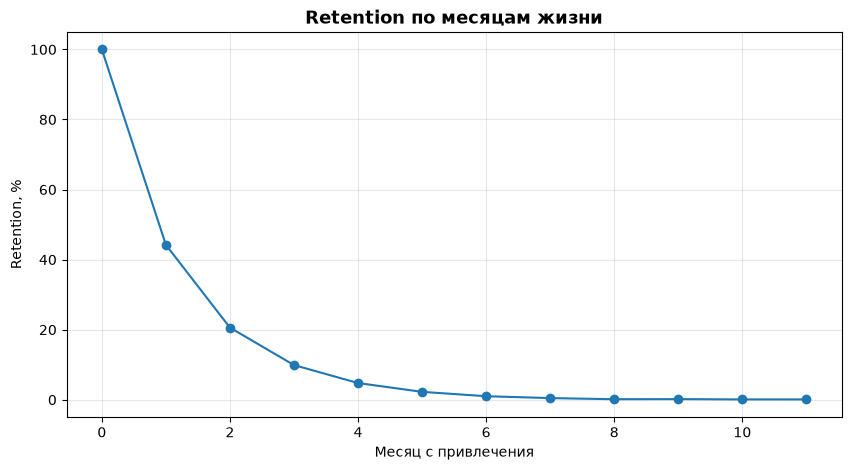

lifetime_month
0     100.0
1      44.2
2      20.6
3       9.9
4       4.8
5       2.2
6       1.0
7       0.5
8       0.1
9       0.2
10      0.1
11      0.1
Name: retention, dtype: float64


In [10]:
#Retention
df_events['first_month'] = df_events.groupby('user_id')['event_month'].transform('min')

cohorts = df_events.groupby(['first_month', 'event_month'])['user_id'].nunique().reset_index()
cohorts.columns = ['cohort_month', 'event_month', 'users']

cohorts['lifetime_month'] = (
    (cohorts['event_month'].dt.year - cohorts['cohort_month'].dt.year) * 12
    + (cohorts['event_month'].dt.month - cohorts['cohort_month'].dt.month)
)

cohort_size = cohorts[cohorts['lifetime_month'] == 0].set_index('cohort_month')['users']
cohorts['retention'] = cohorts['users'] / cohorts['cohort_month'].map(cohort_size) * 100

avg_retention = cohorts.groupby('lifetime_month')['retention'].mean()

plt.figure(figsize=(10, 5))
plt.plot(avg_retention.index, avg_retention.values, marker='o')
plt.title('Retention по месяцам жизни', fontsize=13, fontweight='bold')
plt.xlabel('Месяц с привлечения')
plt.ylabel('Retention, %')
plt.grid(alpha=0.3)
plt.show()

print(avg_retention.round(1))

***Краткий промежуточный вывод по метрикам:***

- Продукт показал сильный рост в первой половине года по увеличению выручки и активной аудитории, но во второй половине года наблюдается снижение выручки и сильное падение ARPU(средний доход на каждого пользователя) - это тревожные сигналы; общая монетизация составляет 20%, а конверсия в покупку составляет 40%. Верхнеуровнево показатель Retention сильно просел уже ко 2 месяцу и продолжил снижаться в течение всего года, эту метрику стоит изучить детальнее в разрезе когорт, чтобы понять где маркетплейс теряет деньги.

## 3. Монетизация и юнит-экономика

Маркетинговый бюджет: 17,762,211 руб.
Привлечено пользователей: 44,151
CAC: 402.31 руб.


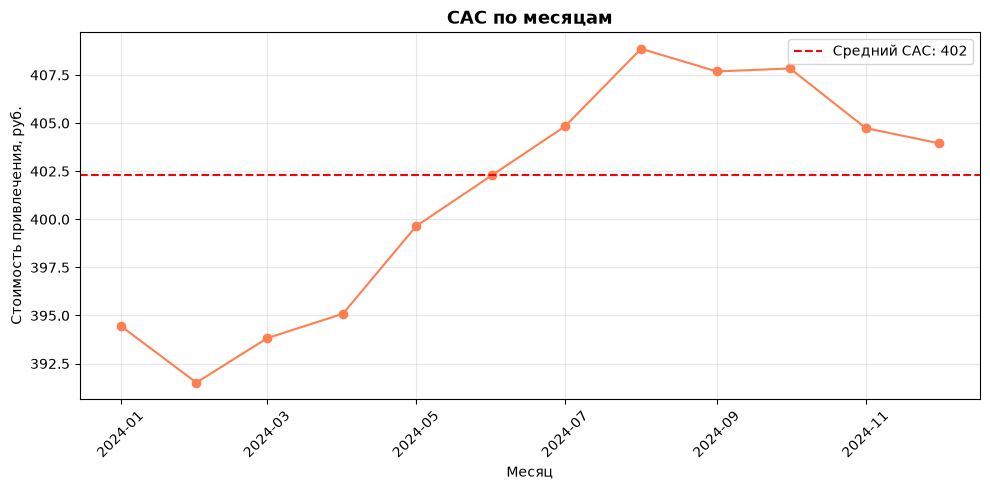

In [11]:
#CAC
total_budget = df_campaign_costs['budget'].sum()
total_users = df_users['user_id'].nunique()
cac = total_budget / total_users

print(f'Маркетинговый бюджет: {total_budget:,.0f} руб.')
print(f'Привлечено пользователей: {total_users:,}')
print(f'CAC: {cac:,.2f} руб.')

monthly_budget = df_campaign_costs.groupby('spend_month')['budget'].sum()
monthly_users = df_users.groupby('cohort_month')['user_id'].nunique()
cac_monthly = monthly_budget / monthly_users

plt.figure(figsize=(10, 5))
plt.plot(cac_monthly.index, cac_monthly.values, marker='o', color='coral')
plt.axhline(cac, color='red', linestyle='--', label=f'Средний CAC: {cac:,.0f}')
plt.title('CAC по месяцам', fontsize=13, fontweight='bold')
plt.xlabel('Месяц')
plt.ylabel('Стоимость привлечения, руб.')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


- CAC вырос с 392–395 в начале года до 404–409 во втором полугодии, то есть на 3–4%.

Выручка маркетплейса: 21,997,211 руб.
LTV: 498.23 руб.


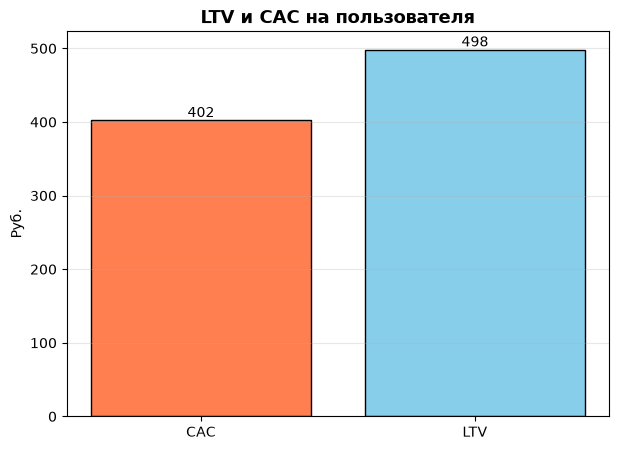

In [12]:
#LTV
total_revenue = df_orders['total_price'].sum() * 0.05   
ltv = total_revenue / total_users

print(f'Выручка маркетплейса: {total_revenue:,.0f} руб.')
print(f'LTV: {ltv:,.2f} руб.')

plt.figure(figsize=(7, 5))
plt.bar(['CAC', 'LTV'], [cac, ltv], color=['coral', 'skyblue'], edgecolor='black')
plt.title('LTV и CAC на пользователя', fontsize=13, fontweight='bold')
plt.ylabel('Руб.')
plt.grid(alpha=0.3, axis='y')
plt.text(0, cac, f'{cac:,.0f}', ha='center', va='bottom')
plt.text(1, ltv, f'{ltv:,.0f}', ha='center', va='bottom')
plt.show()

- Общая выручка с пользователя больше, чем затраченный на его привлечение бюджет - привлечение окупается.

LTV / CAC: 1.24


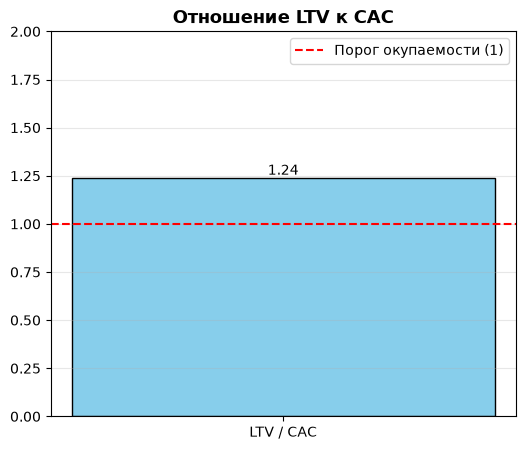

In [13]:
#LTV/CAC
ltv_cac = ltv / cac
print(f'LTV / CAC: {ltv_cac:.2f}')

plt.figure(figsize=(6, 5))
plt.bar(['LTV / CAC'], [ltv_cac], color='skyblue', edgecolor='black', width=0.5)
plt.axhline(1, color='red', linestyle='--', label='Порог окупаемости (1)')
plt.ylim(0, 2)
plt.title('Отношение LTV к CAC', fontsize=13, fontweight='bold')
plt.text(0, ltv_cac, f'{ltv_cac:.2f}', ha='center', va='bottom')
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.show()

- При LTV / CAC = 1,24 - привлечение окупается, но запас небольшой: на рубль затрат приходится 1,24 рубля выручки.

ROI: 23.8%


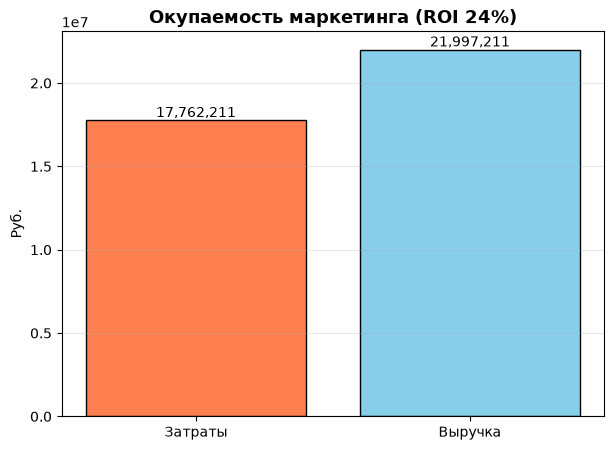

In [14]:
#ROI
roi = (total_revenue - total_budget) / total_budget * 100
print(f'ROI: {roi:.1f}%')

plt.figure(figsize=(7, 5))
plt.bar(['Затраты', 'Выручка'], [total_budget, total_revenue],
        color=['coral', 'skyblue'], edgecolor='black')
plt.title(f'Окупаемость маркетинга (ROI {roi:.0f}%)', fontsize=13, fontweight='bold')
plt.ylabel('Руб.')
plt.grid(alpha=0.3, axis='y')
plt.text(0, total_budget, f'{total_budget:,.0f}', ha='center', va='bottom')
plt.text(1, total_revenue, f'{total_revenue:,.0f}', ha='center', va='bottom')
plt.show()

- Доходность от вложенных средств составляет около 24%, маркетплейс окупается, но запас финансовой подушки у бизнеса небольшой.

Окупаемость: 9.7 мес.


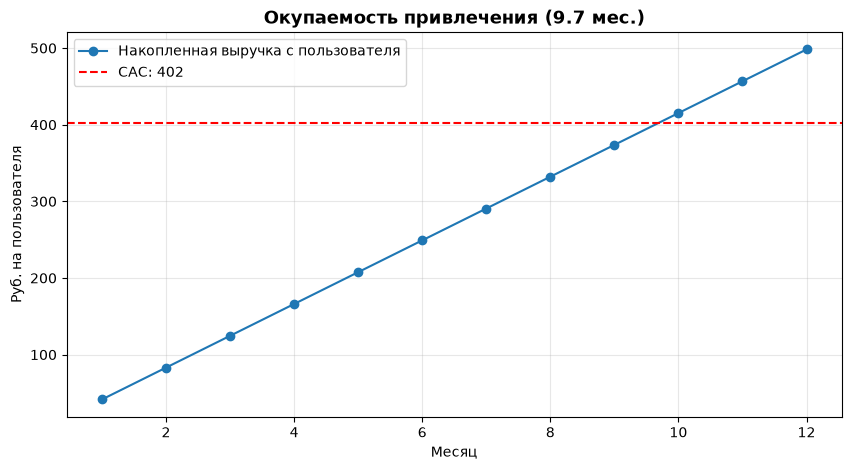

In [15]:
#Payback period
months = df_orders['order_month'].nunique()
arpu_monthly = ltv / months
payback_months = cac / arpu_monthly

print(f'Окупаемость: {payback_months:.1f} мес.')

cumulative = [arpu_monthly * m for m in range(1, months + 1)]

plt.figure(figsize=(10, 5))
plt.plot(range(1, months + 1), cumulative, marker='o', label='Накопленная выручка с пользователя')
plt.axhline(cac, color='red', linestyle='--', label=f'CAC: {cac:,.0f}')
plt.title(f'Окупаемость привлечения ({payback_months:.1f} мес.)', fontsize=13, fontweight='bold')
plt.xlabel('Месяц')
plt.ylabel('Руб. на пользователя')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

- Средний пользователь окупает затраты на своё привлечение за 9,7 месяца, то есть внутри годового горизонта, но поздние когорты окупиться не успевают.

## Выводы: метрики, монетизация, юнит-экономика


 ***Выручка и средний чек***

- Общий оборот 439 944 215, выручка маркетплейса (комиссия 5%) — 21 997 211, AOV по году составляет 14030р (колебания в пределах 10%).

- За первые 5 месяцев выручка выросла в 2,5р, но с осени идет тренд на спад.


***Аудитория и активность***

- DAU/WAU/MAU - показатели активности пользователей активно росли в первую половину года и, несмотря на небольшое снижение дневной и недельной активности, показатель месячной активности остается высоким и не падает ниже 3000 чел.

- Из 44 151 зарегистрированного пользователя события совершают 22 138 — то есть половина аудитории не доходит до первого действия. Это одно из главных узких мест: бюджет на привлечение этой половины потрачен, отдачи нет. Конверсия в покупку от общего числа пользователей - 20%, от активных - 40%.



***Удержание***

- Retention падает быстро: во второй месяц возвращается около 20,6%, к третьему остаётся 9%, после шестого месяца активность практически прекращается. Это означает, что выручка держится на постоянном притоке новых пользователей, а не на повторных покупках существующих.


***Юнит-экономика***

- Привлечение одного пользователя (CAC) - 402р
- Пожизненная ценность клиента (LTV) - 498р
- На 1 вложенный рубль, приходится 1,24 рубля прибыли
- Окупаемость составляет 23,8%, а период окупаемости - 9,7 месяцев
- CAC за год вырос на 3–4% (с 392 до 404 руб.).


***Общий вывод***
- Маркетплейс прибылен, но с небольшим запасом
- Привлечение окупается внутри годового горизонта, но запас минимальный
- Выручка растёт за счёт объёма привлечения, а не за счёт качества монетизации


***Узкие места***

- Доля платящих падает
- Низкая сквозная конверсия
- Слабое удержание
- Минимальный запас прочности в юнит-экономике


## 4. Поиск инсайтов, точек роста и сегментация


,Этап,Пользователей,"От первого шага, %","От предыдущего, %",Потеряно
0,page_view,22098,100.0,NaN,0
1,product_view,22069,99.9,99.9,29
2,product_click,21745,98.4,98.5,324
3,add_to_cart,20411,92.4,93.9,1334
4,checkout_start,16769,75.9,82.2,3642
5,checkout_complete,13897,62.9,82.9,2872
6,paid_order,8922,40.4,64.2,4975


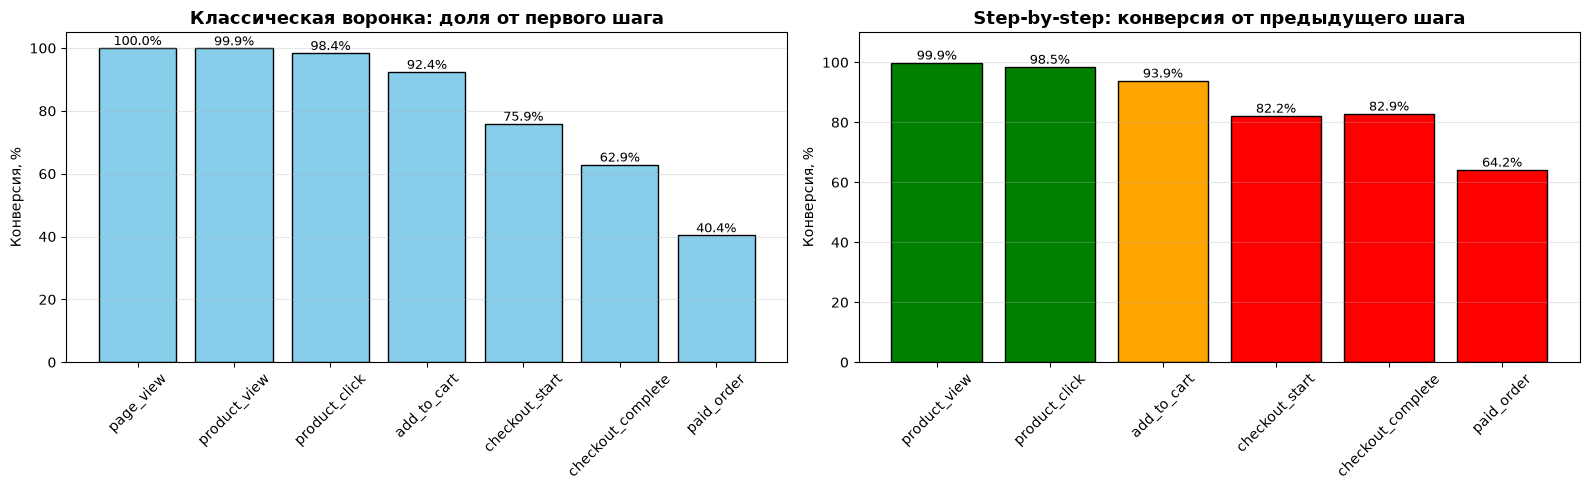

In [16]:
#Строим воронки
#Classic
funnel_steps = ['page_view', 'product_view', 'product_click',
                'add_to_cart', 'checkout_start', 'checkout_complete']

counts = (df_events[df_events['event_type'].isin(funnel_steps)]
          .groupby('event_type')['user_id'].nunique()
          .reindex(funnel_steps))
counts['paid_order'] = df_orders['user_id'].nunique()

funnel = pd.DataFrame({'Этап': counts.index, 'Пользователей': counts.values})
funnel['От первого шага, %'] = (funnel['Пользователей'] / funnel['Пользователей'].iloc[0] * 100).round(1)
funnel['От предыдущего, %'] = (funnel['Пользователей'] / funnel['Пользователей'].shift(1) * 100).round(1)
funnel['Потеряно'] = (funnel['Пользователей'].shift(1) - funnel['Пользователей']).fillna(0).astype(int)

display(funnel)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(funnel['Этап'], funnel['От первого шага, %'], color='skyblue', edgecolor='black')
axes[0].set_title('Классическая воронка: доля от первого шага', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Конверсия, %')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3, axis='y')
for i, v in enumerate(funnel['От первого шага, %']):
    axes[0].text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
    
#Step
step = funnel.iloc[1:]
colors = []
for x in step['От предыдущего, %']:
    if x < 90:
        colors.append('red')
    elif x < 97:
        colors.append('orange')
    else:
        colors.append('green')

axes[1].bar(step['Этап'], step['От предыдущего, %'], color=colors, edgecolor='black')
axes[1].set_title('Step-by-step: конверсия от предыдущего шага', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Конверсия, %')
axes[1].set_ylim(0, 110)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(alpha=0.3, axis='y')
for i, v in enumerate(step['От предыдущего, %']):
    axes[1].text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

- Классическая воронка: 8% пользователей теряется к этапу добавления в корзину, начиная с этапа оформления заказа, воронка сильно проседает, теряя 24% пользователей, затем 37% на этапе завершения оформления и только  40% оплачивают заказы
- Step-by-step: 6% пользователей после клика не добавляет товар в корзину, узкое место также начинается с checkout_start - из добавивших в корзину пользователей 18% не переходит к оформлению заказа, далее еще 18% не заканчивает оформление, 35,8% пользователей завершивших оформление так и не оплачивают заказ
- Таким образом,узкие места в воронках - начало/завершение оформления и фактическая оплата заказов, больше всего пользователей теряется именно на оплате заказов

,users,buyers,revenue,"CR, %",LTV,CAC,"ROI, %"
acq_channel,,,,,,,
Affiliate,6069,2338,6.735815e+06,38.5,1109.87,312.74,254.9
SEO,3312,874,1.909935e+06,26.4,576.67,187.58,207.4
Social Media,4179,1211,3.000255e+06,29.0,717.94,374.07,91.9
Google Ads,9319,3187,8.236760e+06,34.2,883.87,500.43,76.6
Email Marketing,2044,325,5.556987e+05,15.9,271.87,250.35,8.6
TikTok,19228,719,9.104482e+05,3.7,47.35,437.00,-89.2


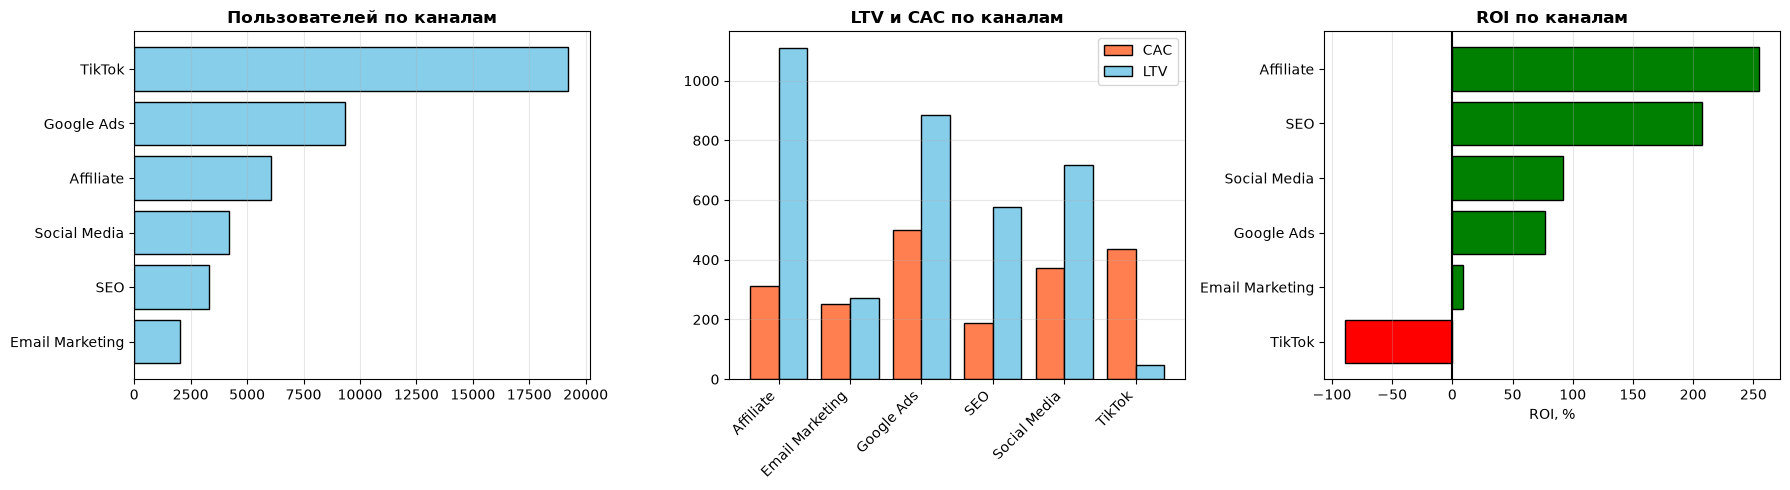

In [17]:
#Выручка по каждому пользователю
revenue_per_user = df_orders.groupby('user_id')['revenue'].sum()

users = df_users.copy()
users['revenue'] = users['user_id'].map(revenue_per_user).fillna(0)
users['is_buyer'] = users['revenue'] > 0

#Сводка по каналам
channel = users.groupby('acq_channel').agg(
    users=('user_id', 'nunique'),
    buyers=('is_buyer', 'sum'),
    revenue=('revenue', 'sum')
)

budget = df_campaign_costs.groupby('acq_channel')['budget'].sum()

channel['CR, %'] = (channel['buyers'] / channel['users'] * 100).round(1)
channel['LTV'] = (channel['revenue'] / channel['users']).round(2)
channel['CAC'] = (budget / channel['users']).round(2)
channel['ROI, %'] = ((channel['LTV'] - channel['CAC']) / channel['CAC'] * 100).round(1)

display(channel.sort_values('ROI, %', ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#Сколько пользователей привёл каждый канал
ch = channel.sort_values('users')
axes[0].barh(ch.index, ch['users'], color='skyblue', edgecolor='black')
axes[0].set_title('Пользователей по каналам', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='x')

#LTV и CAC
x = np.arange(len(channel))
axes[1].bar(x - 0.2, channel['CAC'], 0.4, label='CAC', color='coral', edgecolor='black')
axes[1].bar(x + 0.2, channel['LTV'], 0.4, label='LTV', color='skyblue', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(channel.index, rotation=45, ha='right')
axes[1].set_title('LTV и CAC по каналам', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

#ROI
ch = channel.sort_values('ROI, %')
colors = []
for x in ch['ROI, %']:
    if x < 0:
        colors.append('red')
    else:
        colors.append('green')

axes[2].barh(ch.index, ch['ROI, %'], color=colors, edgecolor='black')
axes[2].axvline(0, color='black')
axes[2].set_title('ROI по каналам', fontsize=12, fontweight='bold')
axes[2].set_xlabel('ROI, %')
axes[2].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

- Канал привлечения TikTok - убыточный канал привлечения, приводя самое большое количество пользователей(19228), показывает самый маленький LTV - 47,35р, при стоимости одного пользователя - 437р,конверсия в покупку всего 3,7% при среднем по остальным каналам 16–39% — трафик нецелевой
- Email Marketing - работает практически в 0. ROI 8,6%, конверсия 15,9% — худшая после TikTok. Канал приводит меньше всего пользователей (2044), поэтому влияние на бизнес небольшое.
- Лучшие показатели окупаемости у каналов Affiliate и SEO - ROI 255% и 207% при самых низких CAC (313 и 188 руб.). Affiliate даёт высокую конверсию 38,5% и LTV 1110 руб. — лучшие показатели среди всех каналов. 
- Google Ads — самый дорогой, но прибыльный. CAC 500 руб., ROI 77%. Даёт наибольшую выручку в абсолюте (8,2 млн руб.) за счёт объёма и хорошей конверсии 34,2%. Но стоит следить за каналом при его дороговизне, чтобы он не стал убыточным

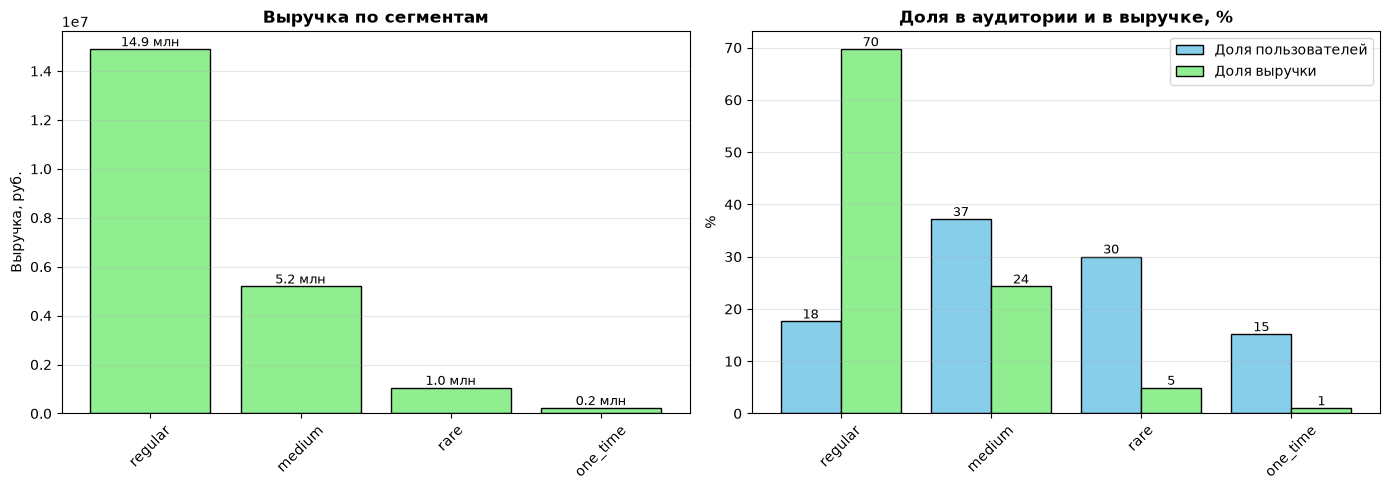

In [18]:
seg = users.groupby('buyer_segment').agg(
    users=('user_id', 'nunique'),
    buyers=('is_buyer', 'sum'),
    revenue=('revenue', 'sum')
)
seg['CR, %'] = (seg['buyers'] / seg['users'] * 100).round(1)
seg['LTV'] = (seg['revenue'] / seg['users']).round(2)
seg['доля выручки, %'] = (seg['revenue'] / seg['revenue'].sum() * 100).round(1)
seg = seg.sort_values('revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Выручка по сегментам
axes[0].bar(seg.index, seg['revenue'], color='lightgreen', edgecolor='black')
axes[0].set_title('Выручка по сегментам', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Выручка, руб.')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3, axis='y')
for i, v in enumerate(seg['revenue']):
    axes[0].text(i, v, f'{v/1e6:.1f} млн', ha='center', va='bottom', fontsize=9)

#Доля в аудитории против доли в выручке
x = np.arange(len(seg))
share_users = seg['users'] / seg['users'].sum() * 100
share_revenue = seg['доля выручки, %']

axes[1].bar(x - 0.2, share_users, 0.4, label='Доля пользователей', color='skyblue', edgecolor='black')
axes[1].bar(x + 0.2, share_revenue, 0.4, label='Доля выручки', color='lightgreen', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(seg.index, rotation=45)
axes[1].set_title('Доля в аудитории и в выручке, %', fontsize=12, fontweight='bold')
axes[1].set_ylabel('%')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')
for i in range(len(seg)):
    axes[1].text(i - 0.2, share_users.iloc[i], f'{share_users.iloc[i]:.0f}', ha='center', va='bottom', fontsize=9)
    axes[1].text(i + 0.2, share_revenue.iloc[i], f'{share_revenue.iloc[i]:.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

- 18% пользователей, которые делают заказы регулярно, формируют 70% выручки (14,9 млн р)
- 37% пользователей средней активности дают 24% выручки (5,2 млн р)
- остальные 45% (rare и one_time) приносят лишь 6% выручки (1,2 млн р)
- Выручка сильно сконцентрирована: только у сегмента regular доля в выручке превышает долю в аудитории, у всех остальных - ниже. Бизнес держится на небольшой группе постоянных покупателей, а почти половина привлечённой аудитории практически не приносит денег.

,orders,buyers,revenue,AOV,"доля выручки, %"
category_name,,,,,
Мебель для дома,979,514,3580998.22,73156.25,16.3
Бытовая техника,1030,546,2248933.06,43668.60,10.2
Украшения и часы,1024,495,1718297.10,33560.49,7.8
Спортивный инвентарь,1000,523,1165361.14,23307.22,5.3
Товары для туризма,970,498,1137317.79,23449.85,5.2
Автотовары,1043,561,1044821.74,20034.93,4.7
Товары для кухни,1237,637,1030401.81,16659.69,4.7
Обувь мужская,1253,730,942481.68,15043.60,4.3
Сумки и аксессуары,1180,711,873491.14,14804.93,4.0


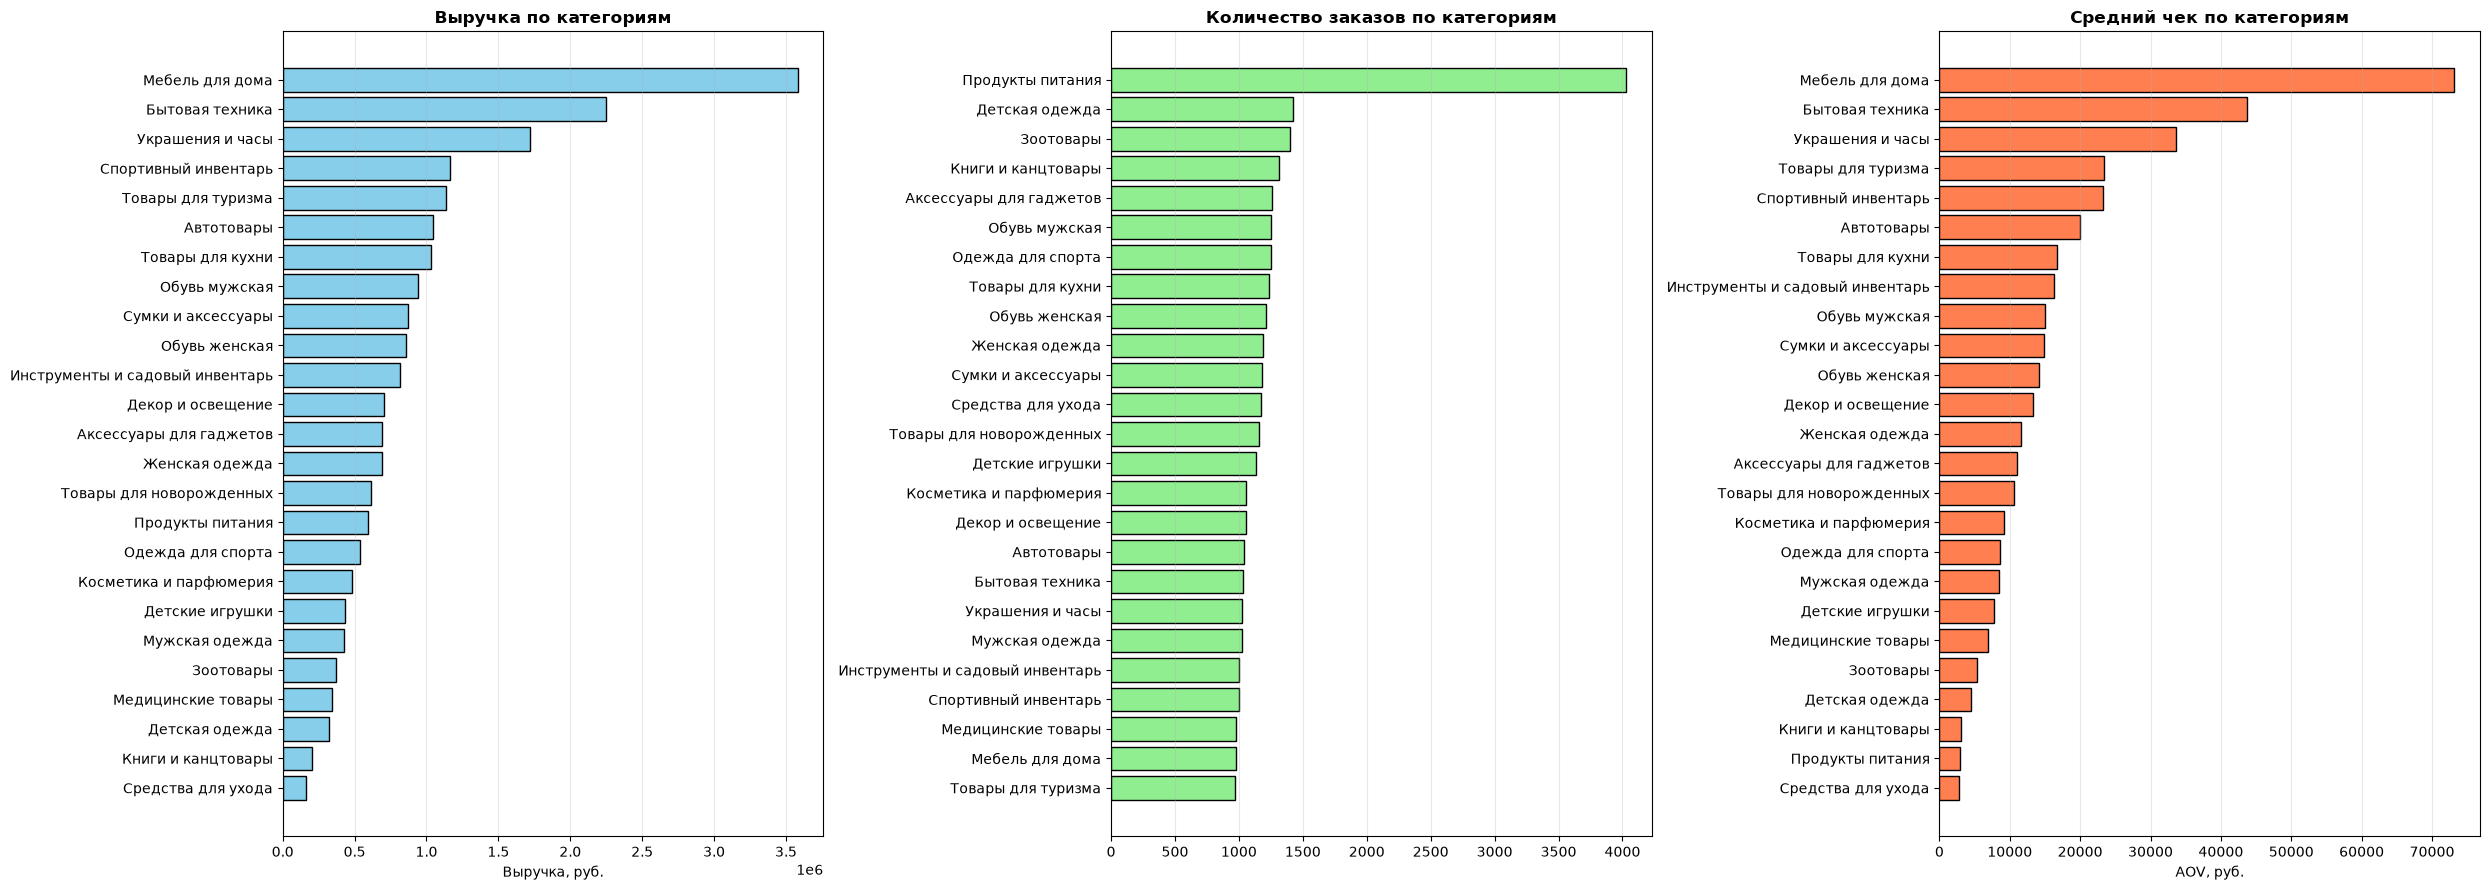

In [19]:
cat = df_orders.groupby('category_name').agg(
    orders=('order_id', 'nunique'),
    buyers=('user_id', 'nunique'),
    revenue=('revenue', 'sum'),
    AOV=('total_price', 'mean')
).round(2)

cat['доля выручки, %'] = (cat['revenue'] / cat['revenue'].sum() * 100).round(1)

display(cat.sort_values('revenue', ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(25, 9))

c = cat.sort_values('revenue')
axes[0].barh(c.index, c['revenue'], color='skyblue', edgecolor='black')
axes[0].set_title('Выручка по категориям', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Выручка, руб.')
axes[0].grid(alpha=0.3, axis='x')

c = cat.sort_values('orders')
axes[1].barh(c.index, c['orders'], color='lightgreen', edgecolor='black')
axes[1].set_title('Количество заказов по категориям', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

c = cat.sort_values('AOV')
axes[2].barh(c.index, c['AOV'], color='coral', edgecolor='black')
axes[2].set_title('Средний чек по категориям', fontsize=12, fontweight='bold')
axes[2].set_xlabel('AOV, руб.')
axes[2].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

- Топ 3 категории по выручке:"Мебель для дома"(16% выручки), "Бытовая техника" (10,2%), "Украшения и часы" (7,8%) - самые доходные за счет большого среднего чека (73 156, 43 668 и 33 560 соответственно); они формируют 34% всей выручки маркетплейса
- Самая популярная категория по количеству заказов - "Продукты питания" (4027 покупателей), далее с большим отрывом идут "Детская одежда" и "Зоотовары" - 1421 и 1396, при этом составляя всего 5,9% выручки


По device:


event_type,page_view,add_to_cart,checkout_start,checkout_complete,"корзина → оформление, %","сквозная, %"
device,,,,,,
desktop,7431,6858,5697,4766,83.1,64.1
mobile,7423,6848,5572,4607,81.4,62.1
tablet,7244,6705,5500,4524,82.0,62.5


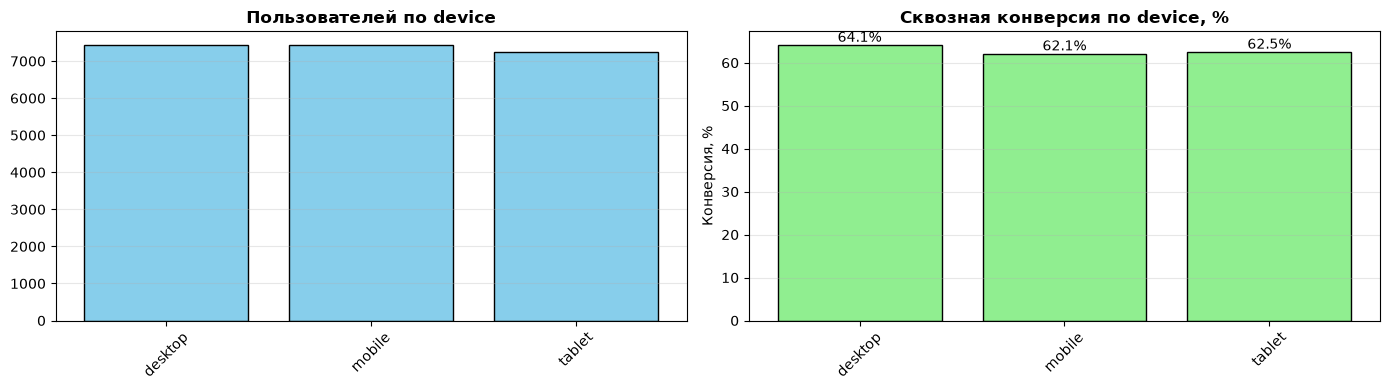


По os:


event_type,page_view,add_to_cart,checkout_start,checkout_complete,"корзина → оформление, %","сквозная, %"
os,,,,,,
Android,5514,5108,4199,3513,82.2,63.7
Windows,5581,5157,4243,3489,82.3,62.5
iOS,5592,5157,4244,3496,82.3,62.5
macOS,5411,4989,4083,3399,81.8,62.8


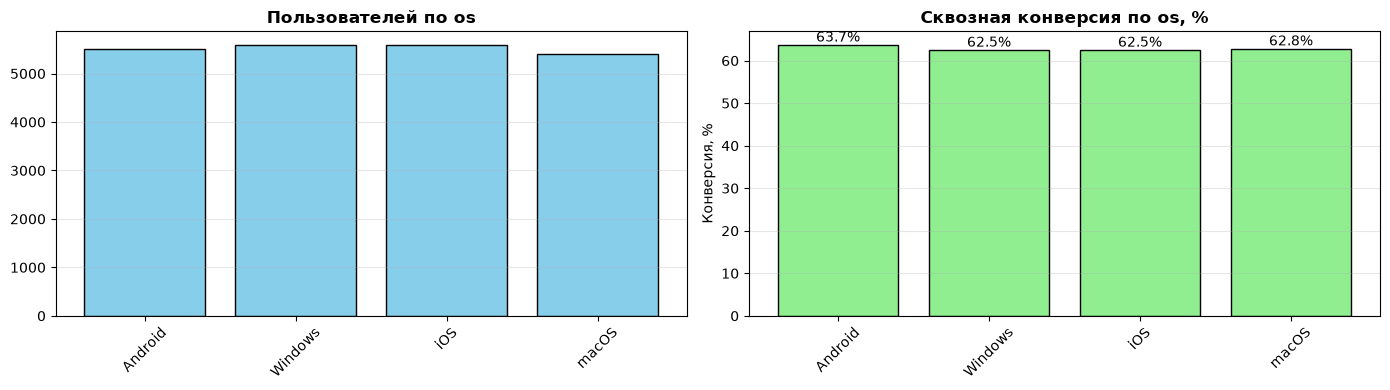

In [20]:
#Активность и воронка по устройствам
funnel_steps = ['page_view', 'add_to_cart', 'checkout_start', 'checkout_complete']

for col in ['device', 'os']:
    dev = (df_events[df_events['event_type'].isin(funnel_steps)]
           .groupby([col, 'event_type'])['user_id'].nunique()
           .unstack()[funnel_steps])

    dev['корзина → оформление, %'] = (dev['checkout_start'] / dev['add_to_cart'] * 100).round(1)
    dev['сквозная, %'] = (dev['checkout_complete'] / dev['page_view'] * 100).round(1)

    print(f'\nПо {col}:')
    display(dev)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].bar(dev.index, dev['page_view'], color='skyblue', edgecolor='black')
    axes[0].set_title(f'Пользователей по {col}', fontsize=12, fontweight='bold')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(alpha=0.3, axis='y')

    axes[1].bar(dev.index, dev['сквозная, %'], color='lightgreen', edgecolor='black')
    axes[1].set_title(f'Сквозная конверсия по {col}, %', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Конверсия, %')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(alpha=0.3, axis='y')
    for i, v in enumerate(dev['сквозная, %']):
        axes[1].text(i, v, f'{v:.1f}%', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

,orders,buyers,revenue,AOV,заказов на покупателя,"доля выручки, %"
region,,,,,,
Другие регионы,9807,2816,6837361.32,13943.84,3.48,32.0
Москва,7949,2200,5410184.15,13612.24,3.61,25.3
Санкт-Петербург,4667,1317,3396292.58,14554.50,3.54,15.9
Московская область,2280,681,1658614.02,14549.25,3.35,7.8
Екатеринбург,1592,418,1143765.90,14368.92,3.81,5.4
Нижний Новгород,1224,354,841422.00,13748.73,3.46,3.9
Краснодар,949,290,728837.63,15360.12,3.27,3.4
Новосибирск,1072,310,728729.05,13595.69,3.46,3.4
Ростов-на-Дону,906,268,603704.79,13326.82,3.38,2.8


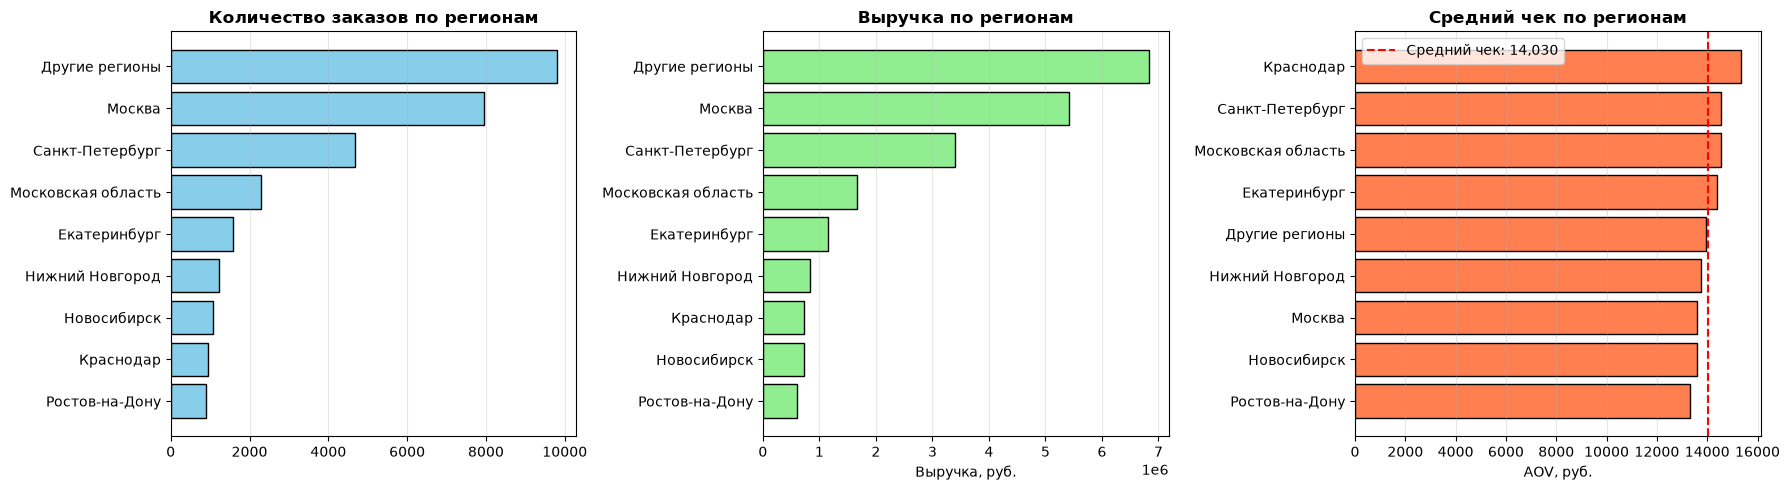

In [21]:
#Присоединяем регион к заказам
orders_region = df_orders.merge(df_users[['user_id', 'region']], on='user_id', how='inner')

region = orders_region.groupby('region').agg(
    orders=('order_id', 'nunique'),
    buyers=('user_id', 'nunique'),
    revenue=('revenue', 'sum'),
    AOV=('total_price', 'mean')
).round(2)

region['заказов на покупателя'] = (region['orders'] / region['buyers']).round(2)
region['доля выручки, %'] = (region['revenue'] / region['revenue'].sum() * 100).round(1)

display(region.sort_values('revenue', ascending=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

r = region.sort_values('orders')
axes[0].barh(r.index, r['orders'], color='skyblue', edgecolor='black')
axes[0].set_title('Количество заказов по регионам', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='x')

r = region.sort_values('revenue')
axes[1].barh(r.index, r['revenue'], color='lightgreen', edgecolor='black')
axes[1].set_title('Выручка по регионам', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Выручка, руб.')
axes[1].grid(alpha=0.3, axis='x')

r = region.sort_values('AOV')
axes[2].barh(r.index, r['AOV'], color='coral', edgecolor='black')
axes[2].axvline(df_orders['total_price'].mean(), color='red', linestyle='--',
                label=f"Средний чек: {df_orders['total_price'].mean():,.0f}")
axes[2].set_title('Средний чек по регионам', fontsize=12, fontweight='bold')
axes[2].set_xlabel('AOV, руб.')
axes[2].legend()
axes[2].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

- По количеству заказов и выручке - 32% составляет сборная категория "Другие регионы" то есть спрос распределен широко за пределами крупных городов, следом идут отдельные крупные мегаполисы - Москва - 25,3% и Санкт-Петербург - 15,9%, остальные представленные регионы вносят менее 10% каждый. 
- При этом пользователи из Краснодара, Санкт-Петербурга, Московской обл и Екатеринбурга делают заказы выше, чем средний чек (14 030), Москва и остальные города делают заказы ниже среднего чека, это значит, что выручка по Санкт-Петербургу достигается за счет дороговизны заказов, а по Москве за счет количества покупателей (2200 против 1317 в Спб)
- Высокий чек (15 360) при малой базе в Краснодаре (290 покупателей) означает, что в Краснодаре есть платежеспособная аудитория, которую можно наращивать и это точка роста


По устройствам:


,users,buyers,revenue,"CR, %",LTV,"доля выручки, %"
device,,,,,,
tablet,7083,2291,6.549658e+06,32.3,924.70,33.7
mobile,7233,2418,6.525681e+06,33.4,902.21,33.6
desktop,7286,2361,6.346303e+06,32.4,871.03,32.7


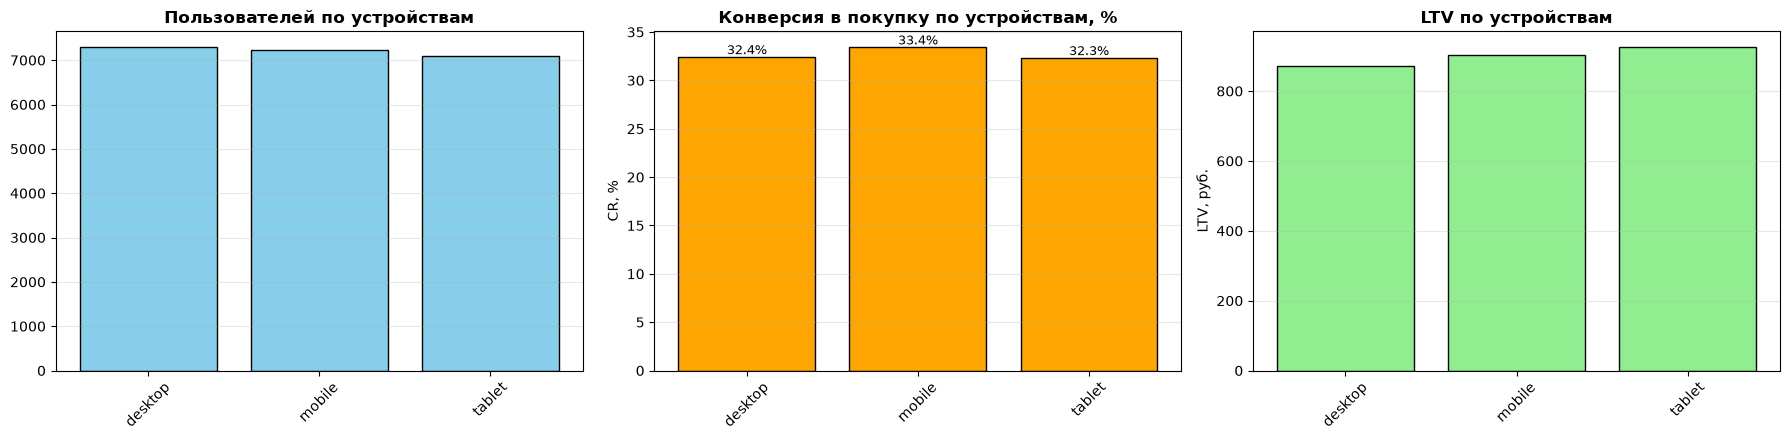


По операционным системам:


,users,buyers,revenue,"CR, %",LTV,"доля выручки, %"
os,,,,,,
iOS,5460,1748,4992151.443,32.0,914.31,25.7
Android,5401,1792,4958230.785,33.2,918.02,25.5
macOS,5269,1739,4895318.092,33.0,929.08,25.2
Windows,5472,1791,4575942.250,32.7,836.25,23.6


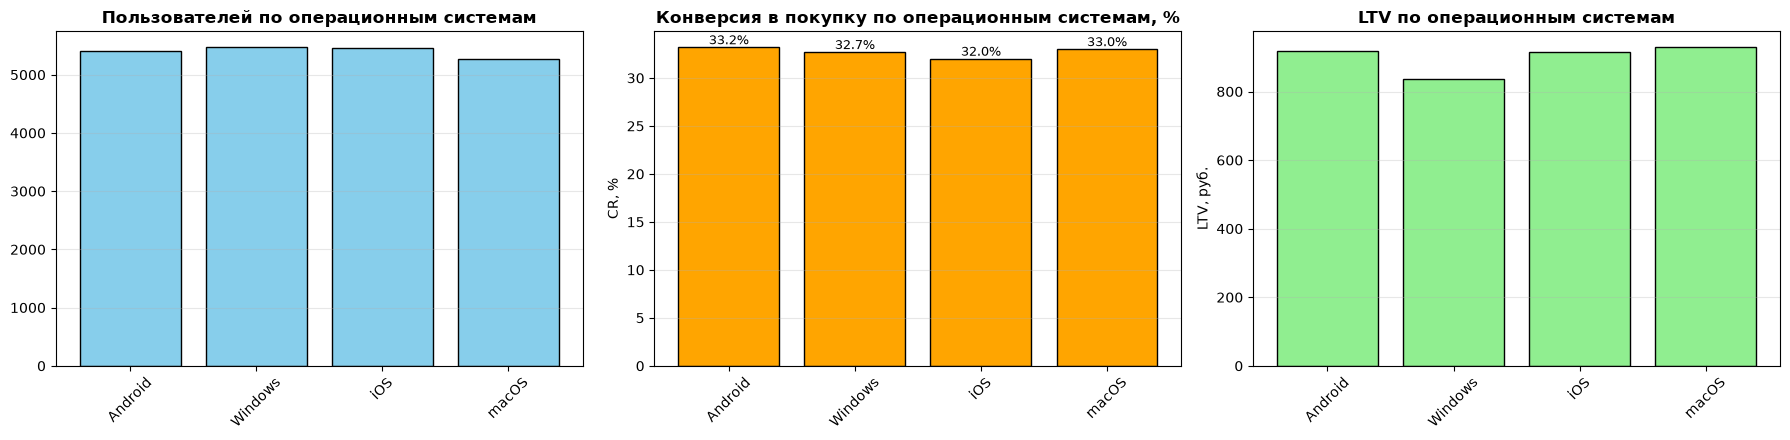

In [22]:
#Определяем основное устройство и ОС пользователя (по большинству его событий)
user_device = (df_events.groupby(['user_id', 'device']).size()
               .reset_index(name='n')
               .sort_values('n', ascending=False)
               .drop_duplicates('user_id')[['user_id', 'device']])

user_os = (df_events.groupby(['user_id', 'os']).size()
           .reset_index(name='n')
           .sort_values('n', ascending=False)
           .drop_duplicates('user_id')[['user_id', 'os']])

tech = users.merge(user_device, on='user_id', how='inner').merge(user_os, on='user_id', how='inner')

for col, name in [('device', 'устройствам'), ('os', 'операционным системам')]:
    t = tech.groupby(col).agg(
        users=('user_id', 'nunique'),
        buyers=('is_buyer', 'sum'),
        revenue=('revenue', 'sum')
    )
    t['CR, %'] = (t['buyers'] / t['users'] * 100).round(1)
    t['LTV'] = (t['revenue'] / t['users']).round(2)
    t['доля выручки, %'] = (t['revenue'] / t['revenue'].sum() * 100).round(1)

    print(f'\nПо {name}:')
    display(t.sort_values('revenue', ascending=False))

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

    axes[0].bar(t.index, t['users'], color='skyblue', edgecolor='black')
    axes[0].set_title(f'Пользователей по {name}', fontsize=12, fontweight='bold')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(alpha=0.3, axis='y')

    axes[1].bar(t.index, t['CR, %'], color='orange', edgecolor='black')
    axes[1].set_title(f'Конверсия в покупку по {name}, %', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('CR, %')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(alpha=0.3, axis='y')
    for i, v in enumerate(t['CR, %']):
        axes[1].text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

    axes[2].bar(t.index, t['LTV'], color='lightgreen', edgecolor='black')
    axes[2].set_title(f'LTV по {name}', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('LTV, руб.')
    axes[2].tick_params(axis='x', rotation=45)
    axes[2].grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

- Сегментация по устройствам и ОС не выявила каких-то заметных различий (аудитория распределена равномерно около 7000 пользователей на устройство и 5400 на ОС, конверсия в покупку колеблется в пределах 32,0–33,4%, LTV — 836–929р) что говорит о том, что узкие места в воронке не связаны с техническими неполадками, причину стоит искать в самом процессе

## Выводы: узкие места и гипотезы

- **В воронке пользовательского пути** есть узкие места на этапах старта/завершения оформления заказа и оплаты, они не связаны с технической проблемой, т.к по сегементации по устройствам и ОС показатели примерно одинаковые, стоит разобраться в самом процессе. **Гипотеза 1: "Если упростить финальные шаги при оформлении (доставка, способы оплаты) - это поднимет сквозную конверсию" (потери там составляют 17,8% и 35,8%)**

- **По каналам трафика:** TikTok приводит 19 228 пользователей, с конверсией в 3%(вероятно, аудитория нецелевая/неплатежеспособная), при этом занимает 8,4 млн из маркетингового бюджета. По каналам Affiliate и SEO окупаемость 254% и 207%. **Гипотеза 2: "Если перераспределить бюджет, затрачиваемый на канал TikTok, в каналы Affiliate и SEO, вырастет выручка без роста затрат"**

- **По сегментации пользователей:** так как у маркетплейса слабое удержание (Retention к марту составляет около 20%), а основную выручку (70%) формируют 18% пользователей, которые регулярно делают заказы, то **Гипотеза 3: "Работа над повторными покупками (перевод покупателей из сегмента medium (а это 37% пользователей) в сегмент regular) увеличит LTV сильнее, чем привлечение новых пользователей".** То есть нужно направить ресурсы на работу с уже привлеченными пользователями, чтобы стимулировать регулярность покупок.

- **По регионам: Гипотеза 4: "Если увеличить охваты в Краснодаре, это увеличит выручку значительнее и быстрее, чем стимуляция покупок в регионах с низким чеком".** Гипотеза построена на лидирующей позиции Краснодара по среднему чеку среди всех регионов (15 360) и небольшом количестве покупателей (290). Регион перспективный.

## 5. Подготовка эксперимента и подведение его результатов

## Вводные по эксперименту

По итогам сегментации команда продукта решила воздействовать на конверсию финансовым стимулом.
Дизайн эксперимента был подготовлен вне этого исследования — моя задача: провести анализ результатов,
сформулировать рекомендации и оценить корректность самого дизайна.

**Гипотеза:** бонус на первую покупку повысит конверсию пользователей, пришедших из TikTok.

**Данные эксперимента:** `events_AB`, `orders_AB`, `sessions_AB`, `users_AB`, `AB_split_users`.

In [23]:
events_AB = pd.read_csv('data/pa_diploma_events_AB.csv',parse_dates=['event_date','event_week','event_month'])
orders_AB = pd.read_csv('data/pa_diploma_orders_AB.csv',parse_dates=['order_date','order_week','order_month'])
sessions_AB = pd.read_csv('data/pa_diploma_sessions_AB.csv',parse_dates=['session_start','session_week','session_month'])
users_AB = pd.read_csv('data/pa_diploma_users_AB.csv',parse_dates=['registration_date','cohort_week','cohort_month'])
split = pd.read_csv('data/pa_diploma_AB_split_users.csv')

In [24]:
#Краткий обзор таблиц с парсингом дат
print('sessions')
print(sessions_AB.info())
display(sessions_AB.head())
print()
print('events')
print(events_AB.info())
display(events_AB.head())
print()
print('orders')
print(orders_AB.info())
display(orders_AB.head())
print()
print('users')
print(users_AB.info())
display(users_AB.head())
print()
print('split')
print(split.info())
display(split.head())

sessions
<class 'pandas.DataFrame'>
RangeIndex: 127407 entries, 0 to 127406
Data columns (total 17 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   session_id       127407 non-null  int64         
 1   user_id          127407 non-null  int64         
 2   session_start    127407 non-null  str           
 3   os               127407 non-null  str           
 4   device           127407 non-null  str           
 5   region           127407 non-null  str           
 6   browser          127407 non-null  str           
 7   country          127407 non-null  str           
 8   entry_path       127407 non-null  str           
 9   path_start       127407 non-null  str           
 10  utm_source       127407 non-null  str           
 11  screen_size      127407 non-null  str           
 12  scroll_depth     127407 non-null  int64         
 13  user_segment     127407 non-null  str           
 14  utm_campaign_id  12707

,session_id,user_id,session_start,os,device,region,browser,country,entry_path,path_start,utm_source,screen_size,scroll_depth,user_segment,utm_campaign_id,session_week,session_month
0,705,160,2024-01-12 02:30:37.000,Windows,mobile,Москва,Safari,Россия,/home,/recommend/10,unknown,768x1024,51,regular,14.0,2024-01-08,2024-01-01
1,706,160,2024-01-10 06:04:41.000,Windows,mobile,Москва,Safari,Россия,/home,/sale/2,unknown,375x667,71,regular,14.0,2024-01-08,2024-01-01
2,707,160,2024-01-23 03:31:16.000,Windows,mobile,Москва,Safari,Россия,/checkout,/click/20,unknown,768x1024,84,regular,14.0,2024-01-22,2024-01-01
3,708,160,2024-01-18 13:43:45.000,Windows,mobile,Москва,Safari,Россия,/category,/campaign/20,unknown,768x1024,20,regular,14.0,2024-01-15,2024-01-01
4,709,160,2024-01-21 01:09:58.000,Windows,mobile,Москва,Safari,Россия,/promo,/sale/3,unknown,1366x768,88,regular,14.0,2024-01-15,2024-01-01



events
<class 'pandas.DataFrame'>
RangeIndex: 831231 entries, 0 to 831230
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   event_id      831231 non-null  int64         
 1   session_id    831231 non-null  int64         
 2   user_id       831231 non-null  int64         
 3   event_date    831231 non-null  datetime64[us]
 4   event_type    831231 non-null  str           
 5   os            831231 non-null  str           
 6   device        831231 non-null  str           
 7   event_index   831231 non-null  int64         
 8   user_segment  831231 non-null  str           
 9   product_name  409054 non-null  str           
 10  event_week    831231 non-null  datetime64[us]
 11  event_month   831231 non-null  datetime64[us]
dtypes: datetime64[us](3), int64(4), str(5)
memory usage: 76.1 MB
None


,event_id,session_id,user_id,event_date,event_type,os,device,event_index,user_segment,product_name,event_week,event_month
0,3132,479,100,2024-01-01 15:23:56,page_view,iOS,mobile,1,regular,NaN,2024-01-01,2024-01-01
1,3133,479,100,2024-01-01 15:24:01,product_view,iOS,mobile,2,regular,Шорты для тренировок,2024-01-01,2024-01-01
2,3134,479,100,2024-01-01 15:24:10,product_click,iOS,mobile,3,regular,Куртка детская,2024-01-01,2024-01-01
3,3135,479,100,2024-01-01 15:25:10,add_to_cart,iOS,mobile,4,regular,Балетки классические,2024-01-01,2024-01-01
4,3136,479,100,2024-01-01 15:25:46,checkout_start,iOS,mobile,5,regular,NaN,2024-01-01,2024-01-01



orders
<class 'pandas.DataFrame'>
RangeIndex: 33280 entries, 0 to 33279
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       33280 non-null  int64         
 1   user_id        33280 non-null  int64         
 2   order_date     33280 non-null  str           
 3   product_name   33280 non-null  str           
 4   quantity       33280 non-null  int64         
 5   unit_price     33280 non-null  float64       
 6   total_price    33280 non-null  float64       
 7   category_name  33280 non-null  str           
 8   order_week     33280 non-null  datetime64[us]
 9   order_month    33280 non-null  datetime64[us]
dtypes: datetime64[us](2), float64(2), int64(3), str(3)
memory usage: 2.5 MB
None


,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
0,1,3,2024-01-19 01:52:52.000,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
1,2,3,2024-01-19 01:52:52.000,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
2,3,3,2024-01-19 01:52:52.000,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
3,4,3,2024-01-25 13:59:38.000,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
4,5,3,2024-01-25 13:59:38.000,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01



users
<class 'pandas.DataFrame'>
RangeIndex: 22196 entries, 0 to 22195
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            22196 non-null  int64         
 1   registration_date  22196 non-null  datetime64[us]
 2   os                 22196 non-null  str           
 3   age                22196 non-null  int64         
 4   device             22196 non-null  str           
 5   gender             22196 non-null  str           
 6   region             22196 non-null  str           
 7   browser            22196 non-null  str           
 8   country            22196 non-null  str           
 9   acq_channel        22196 non-null  str           
 10  campaign_id        22196 non-null  float64       
 11  user_segment       22196 non-null  str           
 12  buyer_segment      22196 non-null  str           
 13  cohort_week        22196 non-null  datetime64[us]
 14  cohort_mon

,user_id,registration_date,os,age,device,gender,region,browser,country,acq_channel,campaign_id,user_segment,buyer_segment,cohort_week,cohort_month
0,18,2024-01-01 05:26:00,Android,49,mobile,M,Екатеринбург,Edge,Россия,TikTok,10.0,спящий,one_time,2024-01-01,2024-01-01
1,22,2024-01-01 17:13:00,iOS,50,tablet,M,Санкт-Петербург,Chrome,Россия,TikTok,43.0,VIP,one_time,2024-01-01,2024-01-01
2,26,2024-01-01 21:15:00,iOS,60,desktop,F,Москва,Firefox,Россия,TikTok,27.0,активный,rare,2024-01-01,2024-01-01
3,33,2024-01-01 14:43:00,iOS,31,desktop,M,Екатеринбург,Firefox,Россия,TikTok,15.0,новичок,rare,2024-01-01,2024-01-01
4,39,2024-01-01 01:13:00,Android,44,tablet,M,Санкт-Петербург,Firefox,Россия,TikTok,15.0,спящий,rare,2024-01-01,2024-01-01



split
<class 'pandas.DataFrame'>
RangeIndex: 2968 entries, 0 to 2967
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   user_id  2968 non-null   int64
 1   group    2968 non-null   str  
dtypes: int64(1), str(1)
memory usage: 46.5 KB
None


,user_id,group
0,44965,control
1,44967,control
2,44968,control
3,44969,treatment
4,44970,control


**Проверка распредления пользователей**

Каналы участников эксперимента:
acq_channel
TikTok    2968
Name: count, dtype: int64

Пользователей, встречающихся в сплите более одного раза: 0
Пользователей в сплите, которых нет в users_AB: 0

Пользователей по группам:
group
control      1503
treatment    1465
Name: user_id, dtype: int64

Доли, %:
group
control      50.6
treatment    49.4
Name: user_id, dtype: float64


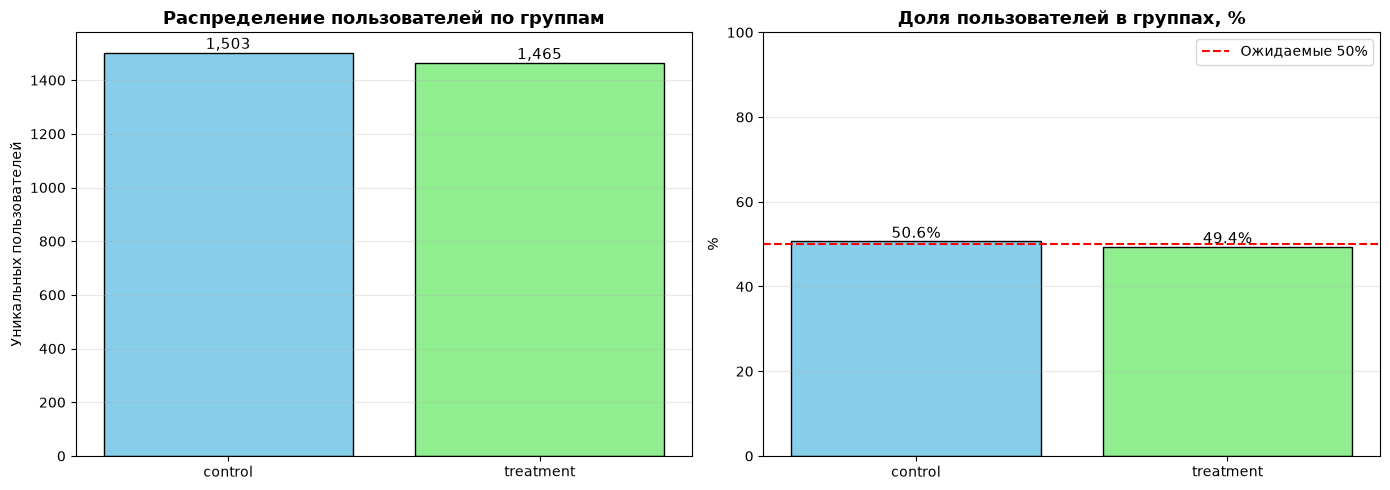

In [25]:
#Проверка распределения пользователей
users_exp = users_AB.merge(split, on='user_id', how='inner')

#Только ли TikTok в эксперименте
print('Каналы участников эксперимента:')
print(users_exp['acq_channel'].value_counts())
print()

#Попал ли кто-то в обе группы
dupes = split['user_id'].duplicated().sum()
print(f'Пользователей, встречающихся в сплите более одного раза: {dupes}')
print('Пользователей в сплите, которых нет в users_AB:',
      len(set(split['user_id']) - set(users_AB['user_id'])))
print()

if dupes > 0:
    both = split[split['user_id'].duplicated(keep=False)].sort_values('user_id')
    print('Примеры дублей:')
    display(both.head(10))

#Размеры групп
group_size = users_exp.groupby('group')['user_id'].nunique()
share = group_size / group_size.sum() * 100

print('Пользователей по группам:')
print(group_size)
print()
print('Доли, %:')
print(share.round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(group_size.index, group_size.values, color=['skyblue', 'lightgreen'], edgecolor='black')
axes[0].set_title('Распределение пользователей по группам', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Уникальных пользователей')
axes[0].grid(alpha=0.3, axis='y')
for i, v in enumerate(group_size.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=11)

axes[1].bar(share.index, share.values, color=['skyblue', 'lightgreen'], edgecolor='black')
axes[1].axhline(50, color='red', linestyle='--', label='Ожидаемые 50%')
axes[1].set_title('Доля пользователей в группах, %', fontsize=13, fontweight='bold')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, 100)
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')
for i, v in enumerate(share.values):
    axes[1].text(i, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

- Пользователи для A/B теста распределены корректно: группы сбалансированы, отклонение от идеала 50/50 допустимое - менее 1%, пользователи в группах уникальные

**Анализ метрик А/В-эксперимента**

**Гипотеза 1. Ключевая метрика**

- H₀: конверсия в первую покупку в treatment и control статистически не различается (CR_treatment = CR_control)
- H₁: конверсия в первую покупку в treatment статистически выше, чем в control (CR_treatment > CR_control)

**Гипотеза 2. Вспомогательная метрика 1**

- H₀: ARPU в treatment и control статистически не различается (ARPU_treatment = ARPU_control)
- H₁: ARPU в treatment и control статистически различается (ARPU_treatment ≠ ARPU_control)

**Гипотеза 3. Вспомогательная метрика 2**

- H₀: ARPPU в treatment и control статистически не различается (ARPPU_treatment = ARPPU_control)
- H₁: ARPPU в treatment и control статистически различается (ARPPU_treatment ≠ ARPPU_control)

**Гипотеза 4. Вспомогательная метрика 3**

- H₀: AOV в treatment и control статистически не различается (AOV_treatment = AOV_control)
- H₁: AOV в treatment и control статистически различается (AOV_treatment ≠ AOV_control)

Период эксперимента: 2025-01-01 — 2025-01-26
Пользователей: control 1,503, treatment 1,465
Покупателей: control 16, treatment 110



,Метрика,Control,Treatment,Абс.,"Отн., %",p-value,Значимо
0,"CR в покупку, %",1.0645,7.5085,6.4440,605.3328,0.0000,да
1,ARPU,12.5873,131.2490,118.6618,942.7138,0.0000,да
2,ARPPU,1182.4153,1747.9986,565.5833,47.8329,0.0493,да
3,AOV,15765.5375,16647.6062,882.0687,5.5949,0.7872,нет
4,Выручка,18918.6450,192279.8515,173361.2065,916.3511,NaN,—


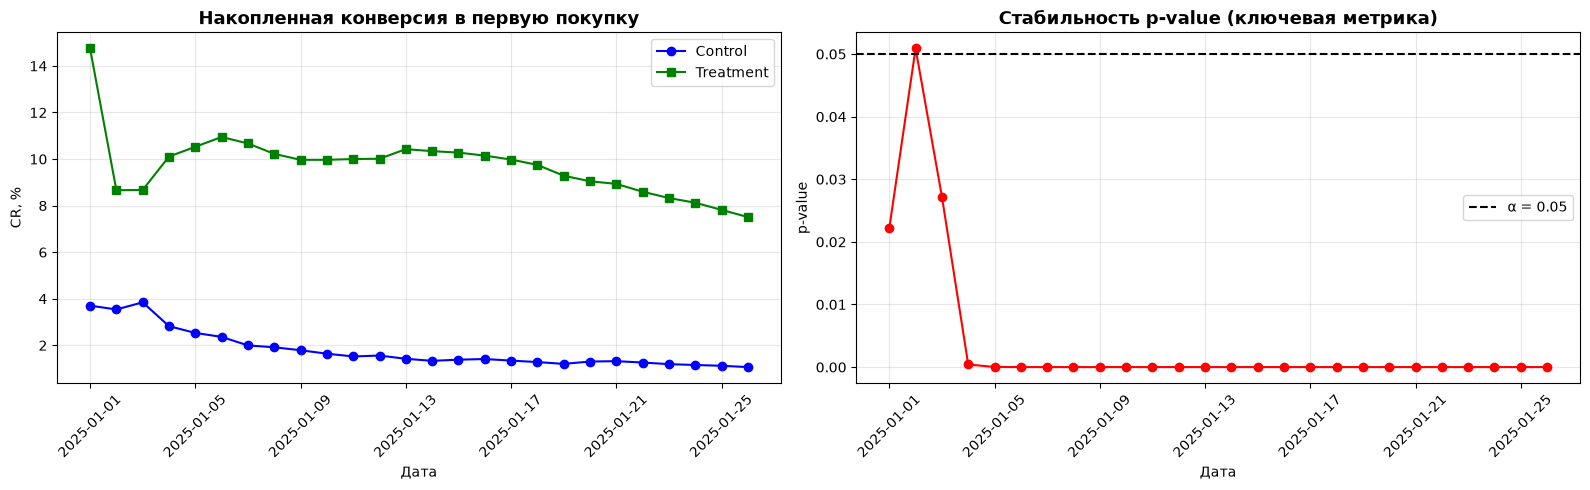

In [26]:
#Подготовка
orders_AB['revenue'] = orders_AB['total_price'] * 0.05

users_exp = users_AB.merge(split, on='user_id', how='inner')

revenue_per_user = orders_AB.groupby('user_id')['revenue'].sum()
users_exp['revenue'] = users_exp['user_id'].map(revenue_per_user).fillna(0)
users_exp['is_buyer'] = users_exp['revenue'] > 0

control = users_exp[users_exp['group'] == 'control']
treatment = users_exp[users_exp['group'] == 'treatment']

#Средний чек
orders_exp = orders_AB.merge(split, on='user_id', how='inner')
aov_c = orders_exp[orders_exp['group'] == 'control']['total_price']
aov_t = orders_exp[orders_exp['group'] == 'treatment']['total_price']

#Метрики
metrics = pd.DataFrame({
    'Метрика': ['CR в покупку, %', 'ARPU', 'ARPPU', 'AOV', 'Выручка'],
    'Control': [
        control['is_buyer'].mean() * 100,
        control['revenue'].mean(),
        control[control['is_buyer']]['revenue'].mean(),
        aov_c.mean(),
        control['revenue'].sum()
    ],
    'Treatment': [
        treatment['is_buyer'].mean() * 100,
        treatment['revenue'].mean(),
        treatment[treatment['is_buyer']]['revenue'].mean(),
        aov_t.mean(),
        treatment['revenue'].sum()
    ]
})

metrics['Абс.'] = metrics['Treatment'] - metrics['Control']
metrics['Отн., %'] = (metrics['Treatment'] / metrics['Control'] - 1) * 100

#Статистическая значимость
p_cr = proportions_ztest(
    count=[treatment['is_buyer'].sum(), control['is_buyer'].sum()],
    nobs=[len(treatment), len(control)],
    alternative='larger'
)[1]

p_arpu = ttest_ind(treatment['revenue'], control['revenue'], equal_var=False).pvalue
p_arppu = ttest_ind(treatment[treatment['is_buyer']]['revenue'],
                    control[control['is_buyer']]['revenue'], equal_var=False).pvalue
p_aov = ttest_ind(aov_t, aov_c, equal_var=False).pvalue

metrics['p-value'] = [p_cr, p_arpu, p_arppu, p_aov, None]

significant = []
for p in metrics['p-value']:
    if pd.isna(p):
        significant.append('—')
    elif p < 0.05:
        significant.append('да')
    else:
        significant.append('нет')

metrics['Значимо'] = significant

print(f"Период эксперимента: {users_exp['registration_date'].min():%Y-%m-%d} — "
      f"{users_exp['registration_date'].max():%Y-%m-%d}")
print(f"Пользователей: control {len(control):,}, treatment {len(treatment):,}")
print(f"Покупателей: control {control['is_buyer'].sum():,}, treatment {treatment['is_buyer'].sum():,}")
print()
display(metrics.round(4))


#Накопленная динамика ключевой метрики и стабильность p-value
users_exp['reg_date'] = users_exp['registration_date'].dt.date
dates = sorted(users_exp['reg_date'].unique())

res = []
for d in dates:
    c = users_exp[(users_exp['group'] == 'control') & (users_exp['reg_date'] <= d)]
    t = users_exp[(users_exp['group'] == 'treatment') & (users_exp['reg_date'] <= d)]

    if c['is_buyer'].sum() + t['is_buyer'].sum() > 0:
        p = proportions_ztest(
            count=[t['is_buyer'].sum(), c['is_buyer'].sum()],
            nobs=[len(t), len(c)],
            alternative='larger'
        )[1]
    else:
        p = 1

    res.append({
        'date': d,
        'cr_control': c['is_buyer'].mean() * 100,
        'cr_treatment': t['is_buyer'].mean() * 100,
        'p_value': p
    })

cum = pd.DataFrame(res)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(cum['date'], cum['cr_control'], marker='o', label='Control', color='blue')
axes[0].plot(cum['date'], cum['cr_treatment'], marker='s', label='Treatment', color='green')
axes[0].set_title('Накопленная конверсия в первую покупку', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Дата')
axes[0].set_ylabel('CR, %')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(cum['date'], cum['p_value'], marker='o', color='red')
axes[1].axhline(0.05, color='black', linestyle='--', label='α = 0.05')
axes[1].set_title('Стабильность p-value (ключевая метрика)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Дата')
axes[1].set_ylabel('p-value')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

- По результатам теста в тестовой группе статистически значимо выросли конверсия в первую покупку (с 1,06% до 7,51%, в 7 раз), ARPU — средний доход на пользователя (с 12,59 до 131,25 руб., в 10 раз) и ARPPU — средний доход на платящего пользователя (с 1182 до 1748 руб., на 48%). Гипотеза подтвердилась.
- Средний чек статистически значимо не изменился (p = 0,79).
- Барьерная метрика — общая выручка — выбрана некорректно: это суммарная величина, по сути дублирующая ARPU. Для неё нельзя провести статистический тест, и она заведомо растёт при раздаче бонусов, поэтому не выполняет свою защитную функцию.
- ARPPU с p = 0,0493 — у самой границы значимости, и в контроле всего 16 покупателей. (этот результат менее надежен, чем остальные)

In [27]:
orders_count = orders_AB.groupby('user_id').size()
users_exp['orders'] = users_exp['user_id'].map(orders_count).fillna(0)
print(users_exp[users_exp['is_buyer']].groupby('group')['orders'].mean().round(2))

group
control      1.5
treatment    2.1
Name: orders, dtype: float64


- Эффект бонуса идёт через количество покупок, а не через их размер. Средний чек между группами значимо не различается (15 766 против 16 648 руб., p = 0,79), однако покупатели в тестовой группе совершают в среднем 2,1 заказа против 1,5 в контрольной. Рост ARPPU на 47,8% объясняется именно большим числом заказов на покупателя.

## Выводы: итоги A/B-теста

**Результаты:**
- **Гипотеза подтвердилась: бонус на первую покупку значимо увеличил конверсию пользователей TikTok.**

- Конверсия в первую покупку: 1,06% → 7,51% (рост в 7 раз), p < 0,001
- ARPU: 12,59 → 131,25 руб. (рост в 10 раз), p < 0,001
- ARPPU: 1182 → 1748 руб. (+47,8%), p = 0,0493
- AOV: 15 766 → 16 648 руб. (+5,6%), p = 0,79 — изменение незначимо
- Выручка: 18,9 тыс. → 192,3 тыс. руб.

**Механика бонуса:**
- Бонус влияет на количество покупок, а не на их размер. Средний чек между группами не различается, но покупатели тестовой группы совершают 2,1 заказа против 1,5 в контрольной. Рост ARPPU объясняется большим числом заказов, а не более дорогими покупками.
- Результат устойчив: p-value опускается ниже порога на четвёртый день эксперимента и остаётся там до конца периода, разрыв между группами сохраняется на всём протяжении теста.

**ARPPU**
- Метрика значима на самой границе (p = 0,0493) и рассчитан по 16 покупателям контрольной группы, поэтому этот результат менее надёжен, чем остальные.

**Рекомендации:**
- Сделть расчет экономики. В дизайне не учтена стоимость бонуса — ключевой параметр решения. При CAC TikTok 437 руб. и историческом LTV 47 руб. канал убыточен, и бонус увеличивает затраты на каждого пользователя. Нужно сопоставить стоимость бонусов с приростом выручки.
- Сравнить с альтернативой. Перераспределение бюджета TikTok (8,4 млн руб. за год) в Affiliate и SEO даёт ROI 255% и 207% без дополнительных затрат. Возможно, это выгоднее, чем вкладываться в починку убыточного канала.
- Проверить долгосрочный эффект. Эксперимент длился менее месяца. Неизвестно, сохранят ли пользователи активность после исчерпания бонуса или вернутся к исходной конверсии.

**Проблемы в дизайне эксперимента:**
- Не рассчитаны мощность и MDE
- Барьерная метрика выбрана некорректно, т.к она агрегированная, а должна быть на пользователя (например, средний чек или выруча минус бонус на пользователя)
- Не указан уровень значимости